In [ ]:
# Imports

from sklearn.datasets import load_digits
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load data

digits = load_digits()
X = digits.data
y = digits.target
df = pd.DataFrame(X, columns=digits.feature_names)
df['target'] = y

In [3]:
# Remove nulls
print(f"Before removing nulls: {df.shape[0]}")
df = df.dropna(how='any',axis=0)
print(f"After removing nulls: {df.shape[0]}")

# Remove duplicates
print(f"Before removing duplicates: {df.shape[0]}")
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape[0]}")

# Remove blanks
df = df.replace('', np.nan)

# Convert all columns to numeric. Errors can be coerced to NaN.
df = df.apply(pd.to_numeric, errors='coerce')

Before removing nulls: 1797
After removing nulls: 1797
Before removing duplicates: 1797
After removing duplicates: 1797


In [24]:
# Data type inspection
print(df.dtypes)

feature_names = digits.feature_names

for col in df.columns:
    print(f"Feature {col}: {df[col].value_counts()}")

pixel_0_0    float64
pixel_0_1    float64
pixel_0_2    float64
pixel_0_3    float64
pixel_0_4    float64
              ...   
pixel_7_4    float64
pixel_7_5    float64
pixel_7_6    float64
pixel_7_7    float64
target         int64
Length: 65, dtype: object
Feature pixel_0_0: pixel_0_0
0.0    1797
Name: count, dtype: int64
Feature pixel_0_1: pixel_0_1
0.0    1531
1.0     128
2.0      67
3.0      32
4.0      22
5.0       9
6.0       3
7.0       3
8.0       2
Name: count, dtype: int64
Feature pixel_0_2: pixel_0_2
0.0     430
2.0     143
1.0     128
3.0     125
5.0     107
4.0     106
7.0     103
6.0      98
10.0     92
9.0      85
8.0      76
13.0     66
11.0     65
15.0     58
12.0     57
16.0     32
14.0     26
Name: count, dtype: int64
Feature pixel_0_3: pixel_0_3
16.0    380
15.0    219
12.0    206
13.0    198
14.0    191
11.0    101
10.0     99
9.0      73
8.0      71
0.0      50
1.0      37
6.0      36
7.0      35
5.0      29
2.0      25
4.0      24
3.0      23
Name: count, dtype: i


pixel_0_0
  Mean: 0.0000
  Median: 0.0000
  Std Dev: 0.0000
  Min: 0.0000
  Max: 0.0000
  Skewness: 0.0000
  Kurtosis: 0.0000

pixel_0_1
  Mean: 0.3038
  Median: 0.0000
  Std Dev: 0.9072
  Min: 0.0000
  Max: 8.0000
  Skewness: 4.0049
  Kurtosis: 19.2467

pixel_0_2
  Mean: 5.2048
  Median: 4.0000
  Std Dev: 4.7548
  Min: 0.0000
  Max: 16.0000
  Skewness: 0.5962
  Kurtosis: -0.8098

pixel_0_3
  Mean: 11.8358
  Median: 13.0000
  Std Dev: 4.2488
  Min: 0.0000
  Max: 16.0000
  Skewness: -1.2447
  Kurtosis: 0.8386

pixel_0_4
  Mean: 11.8481
  Median: 13.0000
  Std Dev: 4.2874
  Min: 0.0000
  Max: 16.0000
  Skewness: -1.1355
  Kurtosis: 0.4516

pixel_0_5
  Mean: 5.7819
  Median: 4.0000
  Std Dev: 5.6664
  Min: 0.0000
  Max: 16.0000
  Skewness: 0.5458
  Kurtosis: -1.1734

pixel_0_6
  Mean: 1.3623
  Median: 0.0000
  Std Dev: 3.3258
  Min: 0.0000
  Max: 16.0000
  Skewness: 2.8506
  Kurtosis: 7.6130

pixel_0_7
  Mean: 0.1297
  Median: 0.0000
  Std Dev: 1.0374
  Min: 0.0000
  Max: 15.0000
  Skewn

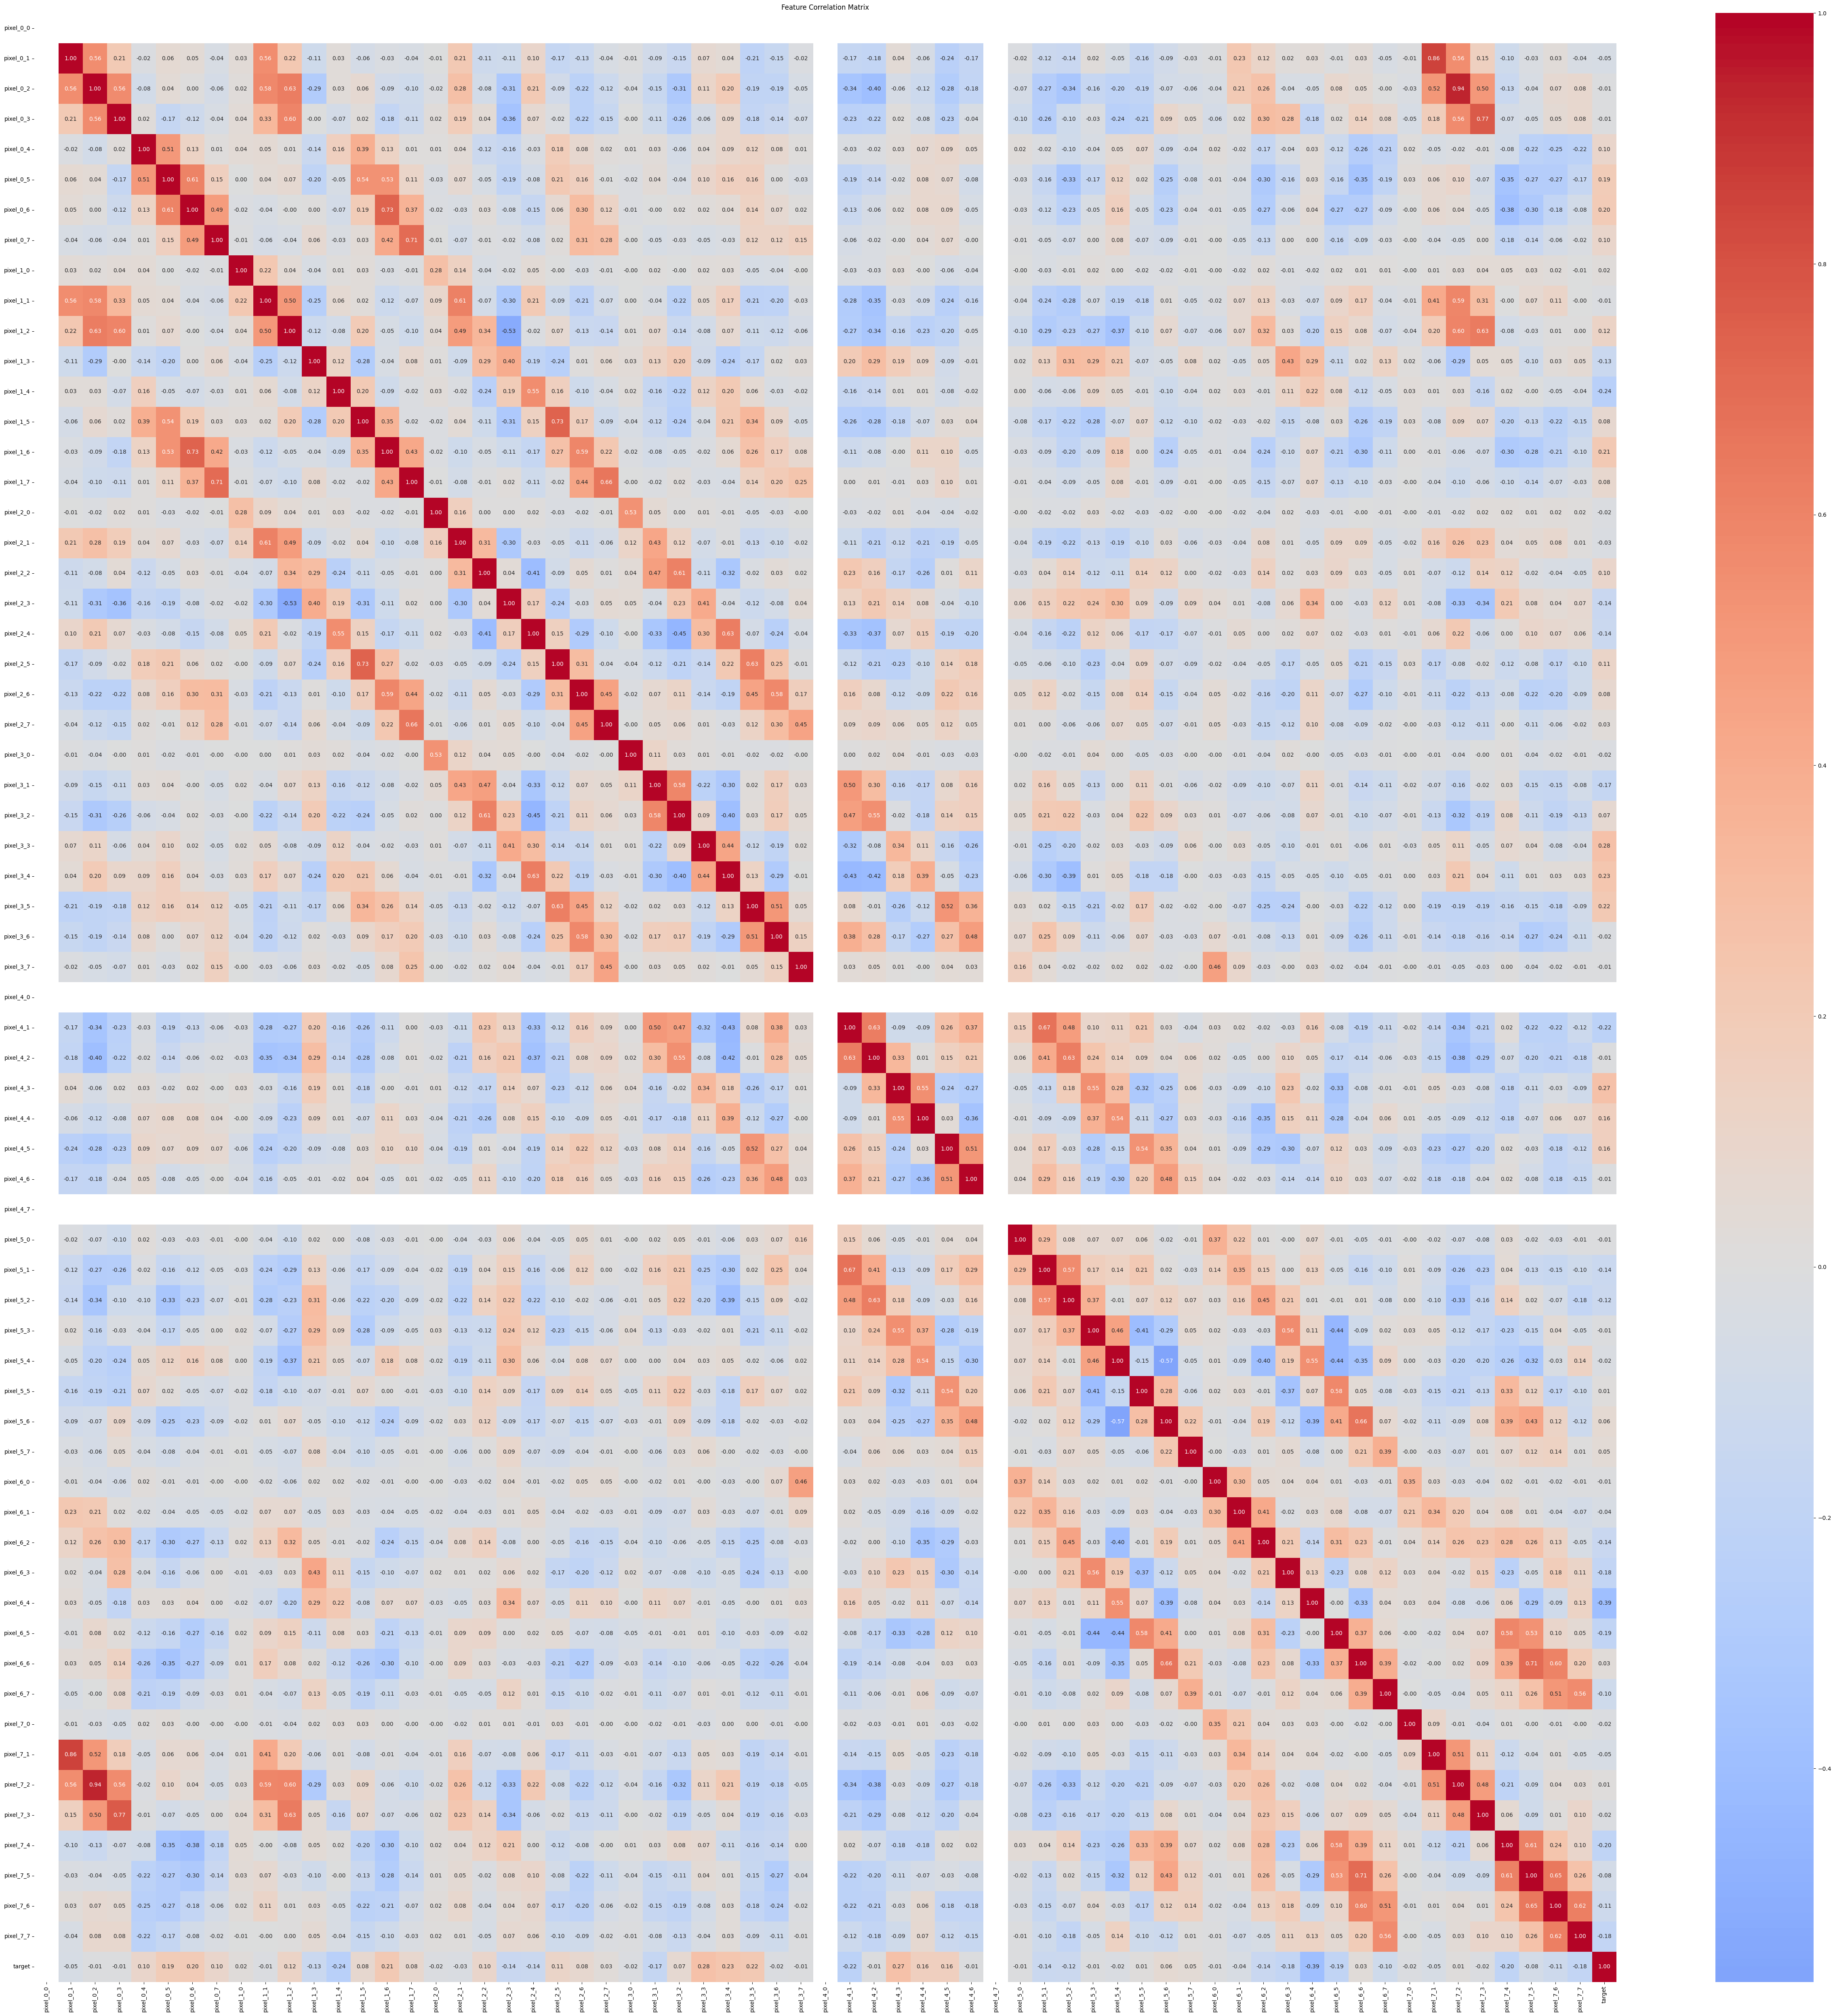

In [25]:
# Statistics
for col in df.columns:
    print(f"\n{col}")
    print(f"  Mean: {df[col].mean():.4f}")
    print(f"  Median: {df[col].median():.4f}")
    print(f"  Std Dev: {df[col].std():.4f}")
    print(f"  Min: {df[col].min():.4f}")
    print(f"  Max: {df[col].max():.4f}")
    print(f"  Skewness: {df[col].skew():.4f}")
    print(f"  Kurtosis: {df[col].kurtosis():.4f}")

plt.figure(figsize=(50, 50))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

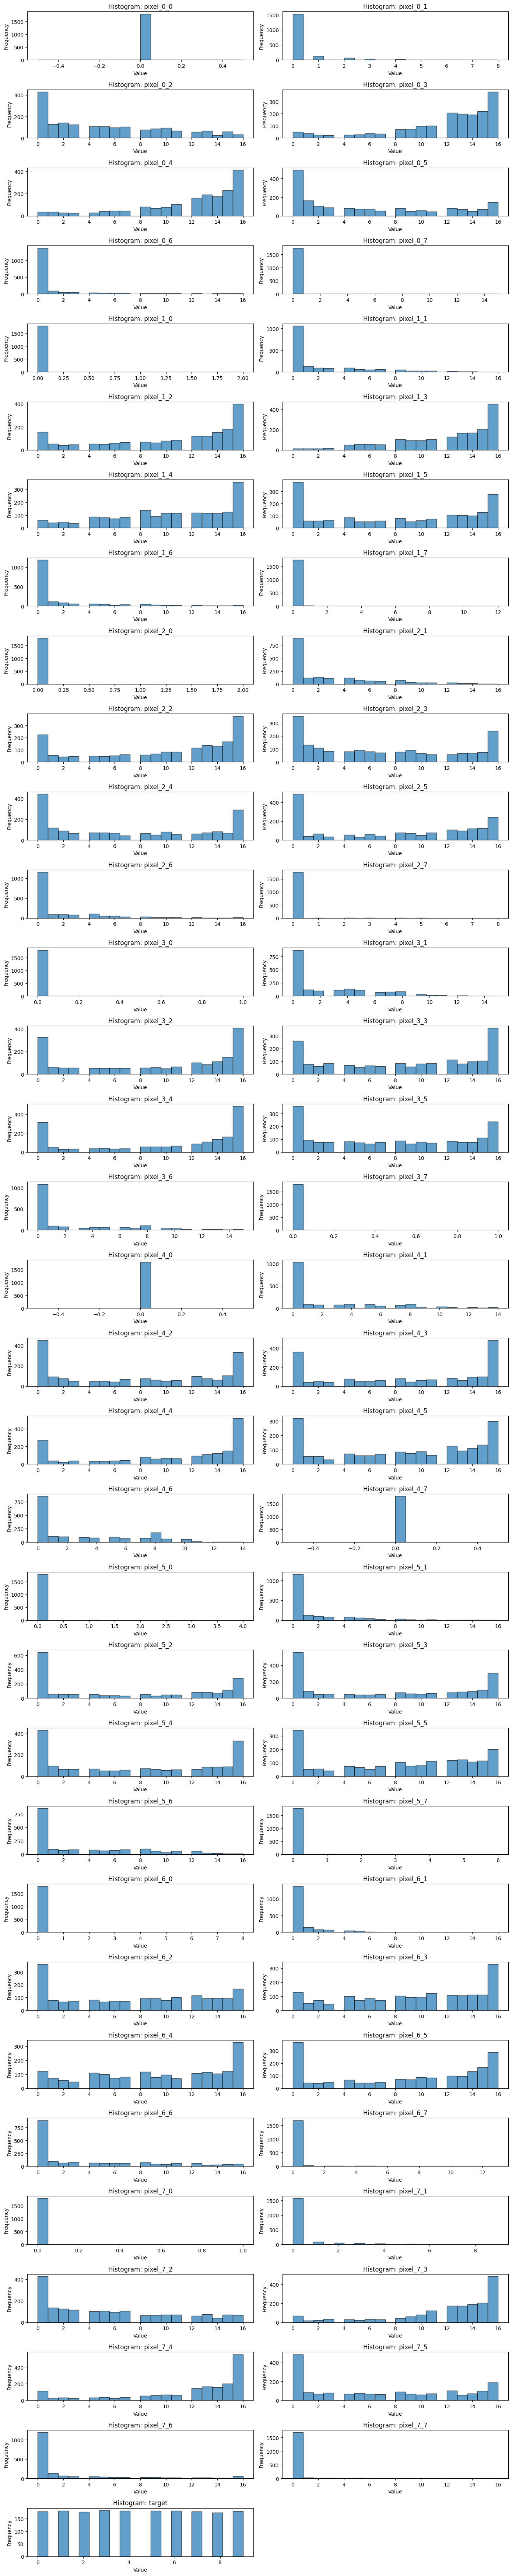

In [6]:
fig, axes = plt.subplots(33, 2, figsize=(14, 70))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Histogram: {col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

# Hide the extra subplot (12th subplot for 11 columns)
axes[-1].set_visible(False)

plt.tight_layout()

plt.show()

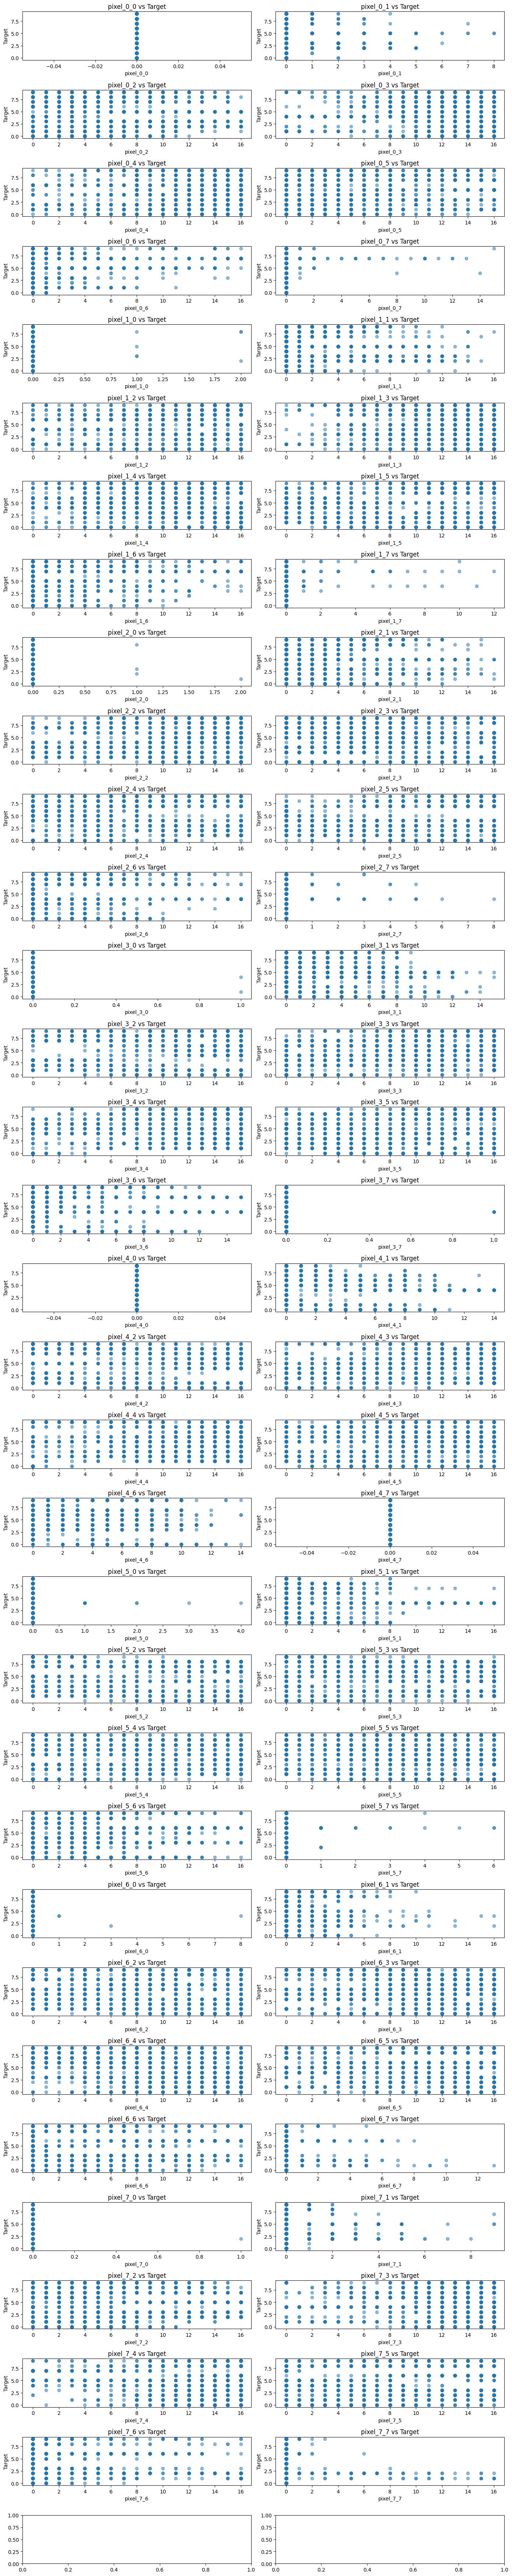

In [26]:
fig, axes = plt.subplots(33, 2, figsize=(14, 70))
axes = axes.ravel()

feature_cols = [col for col in df.columns if col != 'target']
for idx, col in enumerate(feature_cols):
    axes[idx].scatter(df[col], df['target'], alpha=0.5)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Target')
    axes[idx].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

In [4]:
# Remove features (0,0), (7,0), (6, 0), (4, 7), (4, 0), (3, 7), (2, 0), (1, 0), (0, 7), (3, 0), (0, 0) for being constant
df = df.drop(columns=["pixel_0_0", "pixel_7_0", "pixel_6_0", "pixel_4_7", "pixel_4_0", "pixel_3_7", "pixel_2_0", "pixel_1_0", "pixel_0_7", "pixel_3_0", "pixel_0_0"])

# High correlation pairs: (0,1) and (7,1), (0,2) & (7,2), (0,3) & (7,3), (6,6) & (7,5)
df = df.drop(columns=["pixel_0_1", "pixel_0_2", "pixel_0_3", "pixel_7_5"])

In [5]:
class MLP():
    def __init__(self, input_size, hidden_size, output_size, lr):
        random.seed(1)
        # initialize weights and biases for input-hidden and hidden-output layers
        self.hidden_weights = [[random.random() / 100 for i in range(input_size)] for j in range(hidden_size)]
        self.hidden_biases = [random.random() / 100 for j in range(hidden_size)]
        self.output_weights = [[random.random() / 100 for i in range(hidden_size)] for j in range(output_size)]
        self.output_biases = [random.random() / 100 for j in range(output_size)]
        self.lr = lr

    def relu(self, Z):
        # ReLU activation function
        return [max(0, x) for x in Z]

    def relu_derivative(self, Z):
        # derivative of ReLU for backpropagation
        return [1 if x > 0 else 0 for x in Z]

    def softmax(self, Z):
        # softmax function for output layer
        total = sum([np.exp(x) for x in Z])
        return [np.exp(x) / total for x in Z]
    
    def softmax_derivative(self, Z):
        sm = self.softmax(Z)
        return [x * (1 - x) for x in sm]

    def fit(self, X, y, epochs):
        # forward pass: compute hidden and output layer activations
        # compute loss and backpropagate errors
        # update weights and biases
        for e in range(epochs):
            for inp, out in zip(X, y):
                # forward
                predicted = self.predict(inp)
                # backward
                ce_loss_deriv = [predicted[i] - out[i] for i in range(len(out))]
                softmax_deriv = self.softmax_derivative(self.hidden_vals)
                relu_deriv = self.relu_derivative(self.output_vals)
                out_bias_deriv = [ce_loss_deriv[node] * relu_deriv[node] for node in range(len(self.output_biases))]
                out_weight_deriv = [[ce_loss_deriv[node] * relu_deriv[node] * prev_layer_result for prev_layer_result in self.hidden_outputs] for node in range(len(self.output_weights))]
                hidden_bias_deriv = [sum([ce_loss_deriv[i] * softmax_deriv[node] * self.output_weights[i][node] for i in range(len(self.output_weights))]) for node in range(len(self.hidden_biases))]
                hidden_weight_deriv = [[hidden_bias_deriv[node] * softmax_deriv[node] * inp[i] for i in range(len(inp))] for node in range(len(self.hidden_weights))]
                for node in range(len(self.output_biases)):
                    self.output_biases[node] -= self.lr * out_bias_deriv[node]
                    for weight in range(len(self.output_weights[node])):
                        self.output_weights[node][weight] -= self.lr * out_weight_deriv[node][weight]
                for node in range(len(self.hidden_biases)):
                    self.hidden_biases[node] -= self.lr * hidden_bias_deriv[node]
                    for weight in range(len(self.hidden_weights[node])):
                        self.hidden_weights[node][weight] -= self.lr * hidden_weight_deriv[node][weight]

    def predict(self, X):
        # compute predictions for input X
        # return class labels
        self.hidden_vals = [sum([X[j] * self.hidden_weights[i][j] for j in range(len(self.hidden_weights[i]))]) + self.hidden_biases[i] for i in range(len(self.hidden_biases))]
        self.hidden_outputs = self.relu(self.hidden_vals)
        self.output_vals = [sum([self.hidden_outputs[j] * self.output_weights[i][j] for j in range(len(self.output_weights[i]))]) + self.output_biases[i] for i in range(len(self.output_biases))]
        self.outputs = self.softmax(self.output_vals)
        return self.outputs


In [6]:
# Data preprocessing

# one hot encode
encoder = OneHotEncoder(handle_unknown='ignore')
encoder.fit([[1],[2],[3],[4],[5],[6],[7],[8],[9],[0]])
print(encoder.categories_)

encoded_labels = encoder.transform([[x] for x in df['target']]).toarray()
labels = [list(l) for l in encoded_labels]
for i in range(len(labels)):
    for j in range(len(labels[i])):
        labels[i][j] = int(labels[i][j])
print(labels)

# X format
data = [list(l) for l in df.values]
for i in range(len(data)):
    for j in range(len(data[i])):
        data[i][j] = int(data[i][j])

scaler = StandardScaler()
data = scaler.fit_transform(data)
print(data)

# train test split
train_x = data[:int(len(data) * 0.7)]
train_y = labels[:int(len(labels) * 0.7)]
test_x = data[int(len(data) * 0.7):]
test_y = labels[int(len(labels) * 0.7):]

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])]
[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],

In [7]:
learning_rates = [0.001, 0.0005]
hidden_sizes = [len(train_x[0]), int(len(train_x[0]) * 1.5), len(train_x[0]) * 2]
epochs = [500, 1000]
in_size = len(train_x[0])
out_size = len(train_y[0])

total = len(test_x)

for lr in learning_rates:
    for hidden_size in hidden_sizes:
        for epoch_num in epochs:
            # train
            mlp = MLP(in_size, hidden_size, out_size, lr)
            mlp.fit(train_x, train_y, epoch_num)

            # test
            successes = 0
            for x, y in zip(test_x, test_y):
                predicted = mlp.predict(x)
                max_class = max(predicted)
                if predicted.index(max_class) == y.index(1):
                    successes += 1
            print(f"LR {lr}, Hidden Size {hidden_size}, Epochs {epoch_num}: {successes * 100 / total}% Success Rate")

LR 0.001, Hidden Size 51, Epochs 500: 79.62962962962963% Success Rate
LR 0.001, Hidden Size 51, Epochs 1000: 86.29629629629629% Success Rate
LR 0.001, Hidden Size 76, Epochs 500: 86.11111111111111% Success Rate
LR 0.001, Hidden Size 76, Epochs 1000: 90.74074074074075% Success Rate
LR 0.001, Hidden Size 102, Epochs 500: 81.29629629629629% Success Rate
LR 0.001, Hidden Size 102, Epochs 1000: 89.44444444444444% Success Rate
LR 0.0005, Hidden Size 51, Epochs 500: 77.22222222222223% Success Rate
LR 0.0005, Hidden Size 51, Epochs 1000: 87.4074074074074% Success Rate
LR 0.0005, Hidden Size 76, Epochs 500: 62.77777777777778% Success Rate
LR 0.0005, Hidden Size 76, Epochs 1000: 85.92592592592592% Success Rate
LR 0.0005, Hidden Size 102, Epochs 500: 56.666666666666664% Success Rate
LR 0.0005, Hidden Size 102, Epochs 1000: 81.66666666666667% Success Rate


In [ ]:
# learning_rates = [0.1, 0.01, 0.001]
# hidden_sizes = [len(train_x[0]), int(len(train_x[0]) * 1.5), len(train_x[0]) * 2]
# epochs = [20, 50, 100]
# in_size = len(train_x[0])
# out_size = len(train_y[0])

# total = len(test_x)

# for lr in learning_rates:
#     for hidden_size in hidden_sizes:
#         for epoch_num in epochs:
#             # train
#             mlp = MLP(in_size, hidden_size, out_size, lr)
#             mlp.fit(train_x, train_y, epoch_num)

#             # test
#             successes = 0
#             for x, y in zip(test_x, test_y):
#                 predicted = mlp.predict(x)
#                 max_class = max(predicted)
#                 if predicted.index(max_class) == y.index(1):
#                     successes += 1
#             print(f"LR {lr}, Hidden Size {hidden_size}, Epochs {epoch_num}: {successes * 100 / total}% Success Rate")

LR 0.1, Hidden Size 51, Epochs 20: 37.407407407407405% Success Rate
LR 0.1, Hidden Size 51, Epochs 50: 29.074074074074073% Success Rate
LR 0.1, Hidden Size 51, Epochs 100: 27.59259259259259% Success Rate
LR 0.1, Hidden Size 76, Epochs 20: 28.703703703703702% Success Rate
LR 0.1, Hidden Size 76, Epochs 50: 20.185185185185187% Success Rate
LR 0.1, Hidden Size 76, Epochs 100: 18.51851851851852% Success Rate
LR 0.1, Hidden Size 102, Epochs 20: 19.62962962962963% Success Rate
LR 0.1, Hidden Size 102, Epochs 50: 27.77777777777778% Success Rate
LR 0.1, Hidden Size 102, Epochs 100: 40.0% Success Rate
LR 0.01, Hidden Size 51, Epochs 20: 34.25925925925926% Success Rate
LR 0.01, Hidden Size 51, Epochs 50: 36.48148148148148% Success Rate
LR 0.01, Hidden Size 51, Epochs 100: 44.629629629629626% Success Rate
LR 0.01, Hidden Size 76, Epochs 20: 38.148148148148145% Success Rate
LR 0.01, Hidden Size 76, Epochs 50: 45.370370370370374% Success Rate
LR 0.01, Hidden Size 76, Epochs 100: 52.03703703703704% 

In [30]:
# Train best
mlp = MLP(len(train_x[0]), 51, len(train_y[0]), 0.005)
mlp.fit(train_x, train_y, 500)

<Figure size 800x800 with 0 Axes>

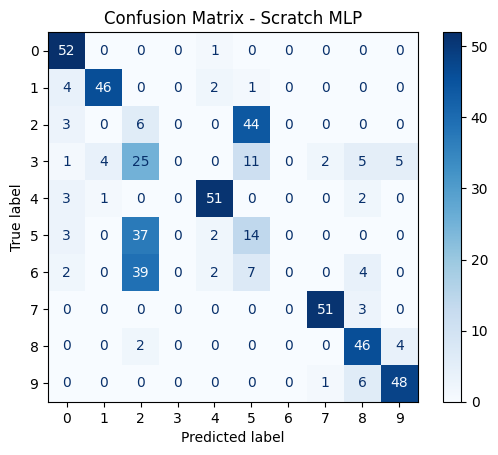

In [36]:

y_pred = [mlp.predict(x) for x in test_x]
pred_labels = []
for pred in y_pred:
    max_pred = max(pred)
    ind = pred.index(max_pred)
    pred_labels.append(ind)
y_labels = []
for y in test_y:
    ind = y.index(1)
    y_labels.append(ind)
cm = confusion_matrix(y_labels, pred_labels)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0,1,2,3,4,5,6,7,8,9]
)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Scratch MLP")
plt.show()

Diabetes Dataset


In [ ]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y
print(f"Features: {list(diabetes.feature_names)}")

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [2]:
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [3]:
# Check for missing values
print(df.isnull().sum())

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [4]:
# Check data types and convert if necessary
print(df.dtypes)

age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object


In [5]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any 
df = df.drop_duplicates()

Duplicate rows: 0


In [6]:
# Statistical summary
print("Statistical Summary:")
print(df.describe())

print("\n" + "="*60)
print("Detailed Statistics:")
print("="*60)

for col in df.columns:
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():.4f}")
    print(f"  Median: {df[col].median():.4f}")
    print(f"  Std Dev: {df[col].std():.4f}")
    print(f"  Min: {df[col].min():.4f}")
    print(f"  Max: {df[col].max():.4f}")
    print(f"  Skewness: {df[col].skew():.4f}")
    print(f"  Kurtosis: {df[col].kurtosis():.4f}")

Statistical Summary:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17   
std    4.761905e-02  4.761905e

Correlation Matrix:
             age       sex       bmi        bp        s1        s2        s3  \
age     1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
sex     0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
bmi     0.185085  0.088161  1.000000  0.395411  0.249777  0.261170 -0.366811   
bp      0.335428  0.241010  0.395411  1.000000  0.242464  0.185548 -0.178762   
s1      0.260061  0.035277  0.249777  0.242464  1.000000  0.896663  0.051519   
s2      0.219243  0.142637  0.261170  0.185548  0.896663  1.000000 -0.196455   
s3     -0.075181 -0.379090 -0.366811 -0.178762  0.051519 -0.196455  1.000000   
s4      0.203841  0.332115  0.413807  0.257650  0.542207  0.659817 -0.738493   
s5      0.270774  0.149916  0.446157  0.393480  0.515503  0.318357 -0.398577   
s6      0.301731  0.208133  0.388680  0.390430  0.325717  0.290600 -0.273697   
target  0.187889  0.043062  0.586450  0.441482  0.212022  0.174054 -0.394789   

              s4   

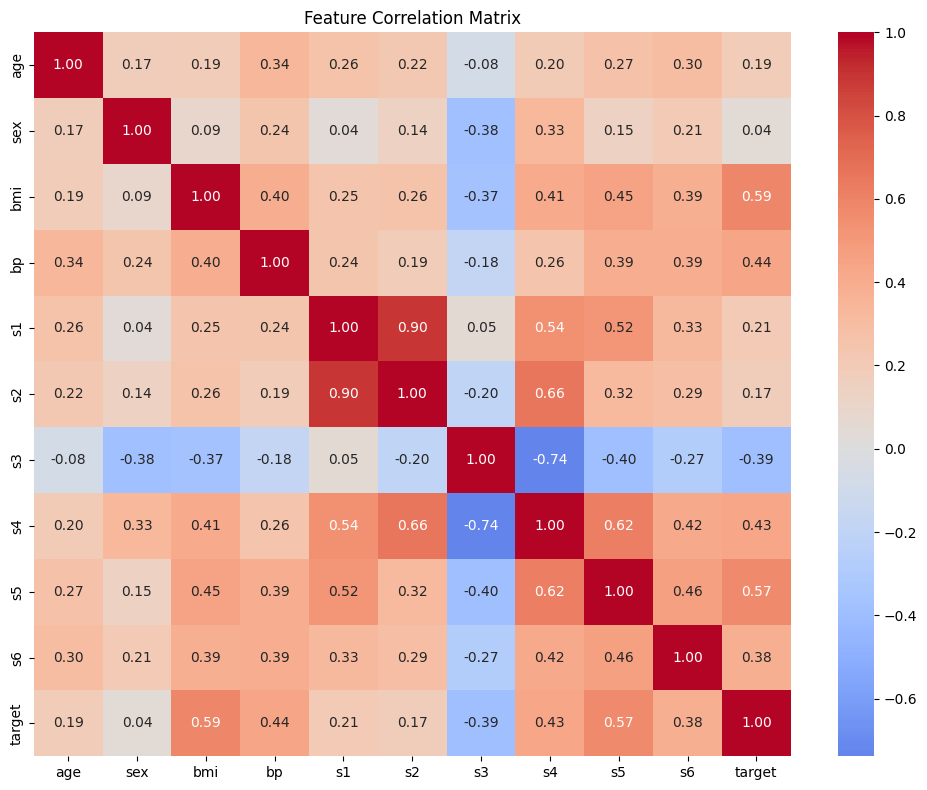


Highly correlated feature pairs (|correlation| > 0.7):
s1 <-> s2: 0.8967
s3 <-> s4: -0.7385


In [ ]:
# Correlation analysis

print("Correlation Matrix:")
correlation_matrix = df.corr()
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Identify highly correlated features
print("\nHighly correlated feature pairs (|correlation| > 0.7):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {corr_val:.4f}")

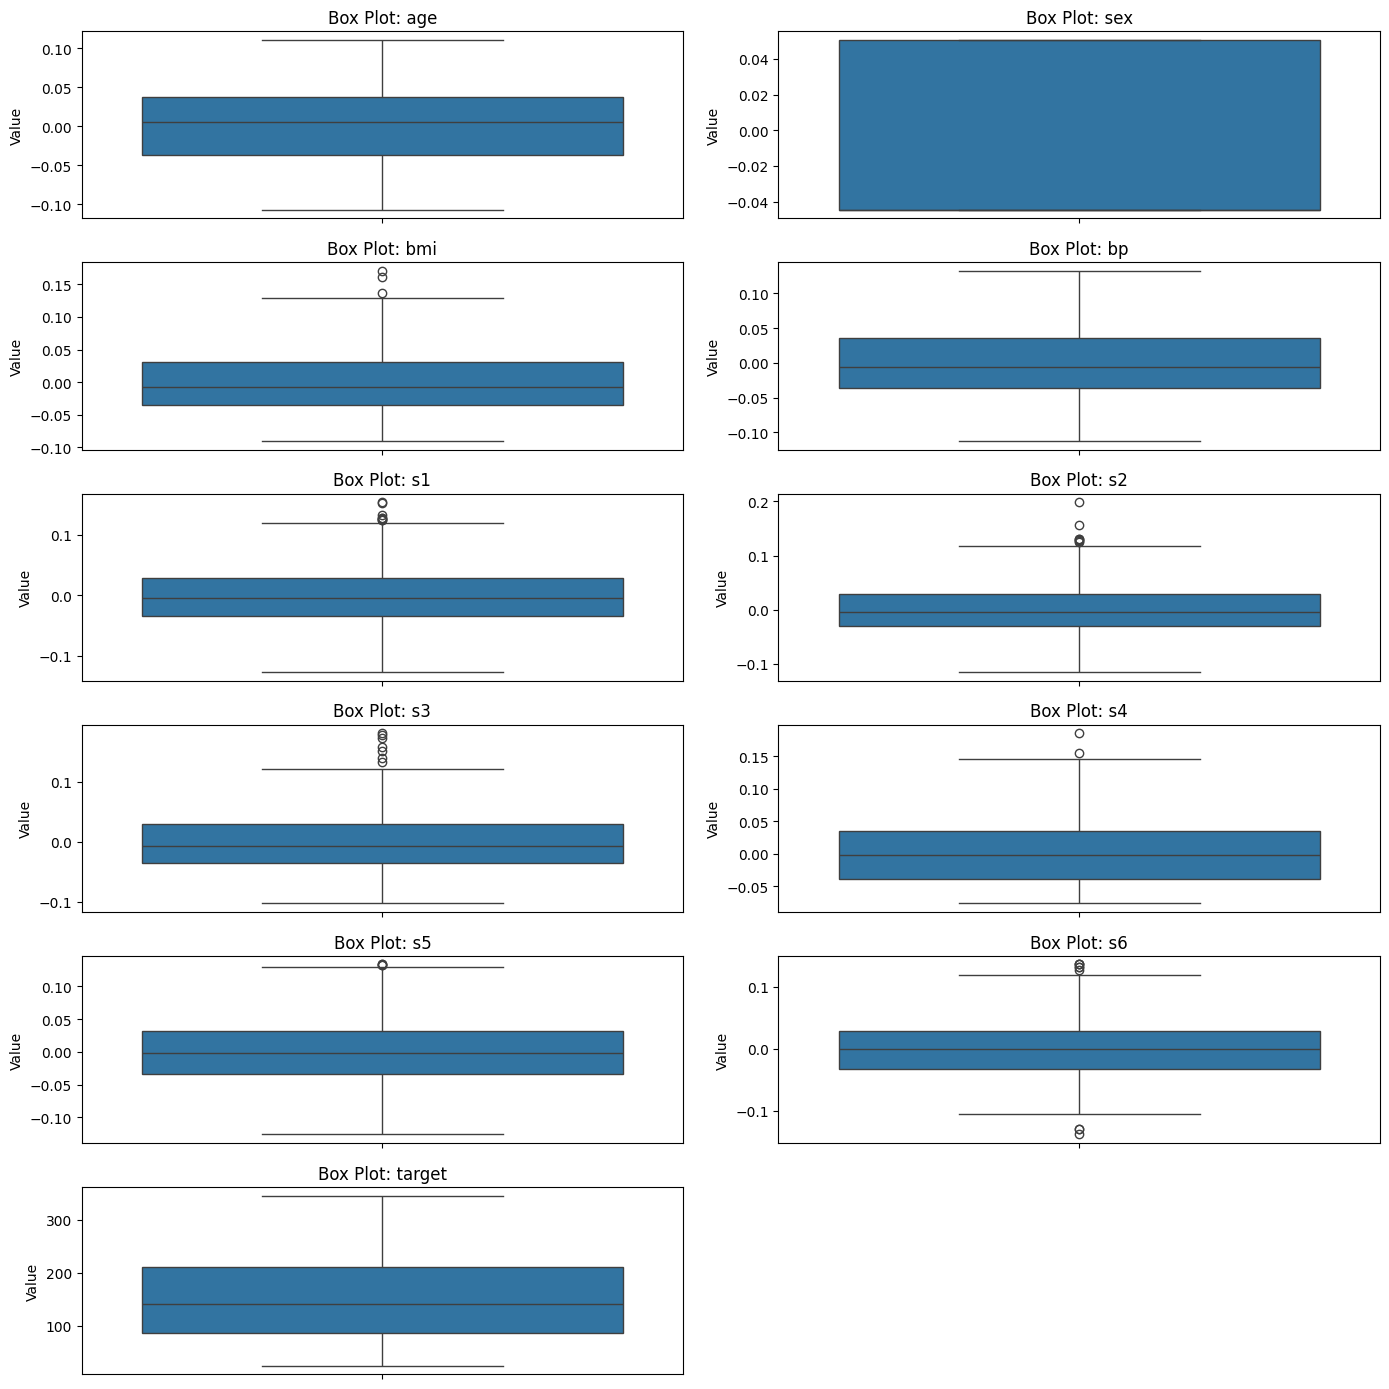


Box plots show potential outliers (dots outside whiskers) and distribution skewness. 
I have decided not to remove outliers as they may contain important information and 
the dataset is not large enough to risk losing data points.


In [8]:
# Box plots for each feature (to detect outliers and distribution)
fig, axes = plt.subplots(6, 2, figsize=(14, 14))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[idx])
    axes[idx].set_title(f'Box Plot: {col}')
    axes[idx].set_ylabel('Value')

# Hide the extra subplot (12th subplot for 11 columns)
axes[-1].set_visible(False)

plt.tight_layout()

plt.show()
print("\nBox plots show potential outliers (dots outside whiskers) and distribution skewness. " 
      "\nI have decided not to remove outliers as they may contain important information and "
      "\nthe dataset is not large enough to risk losing data points.")


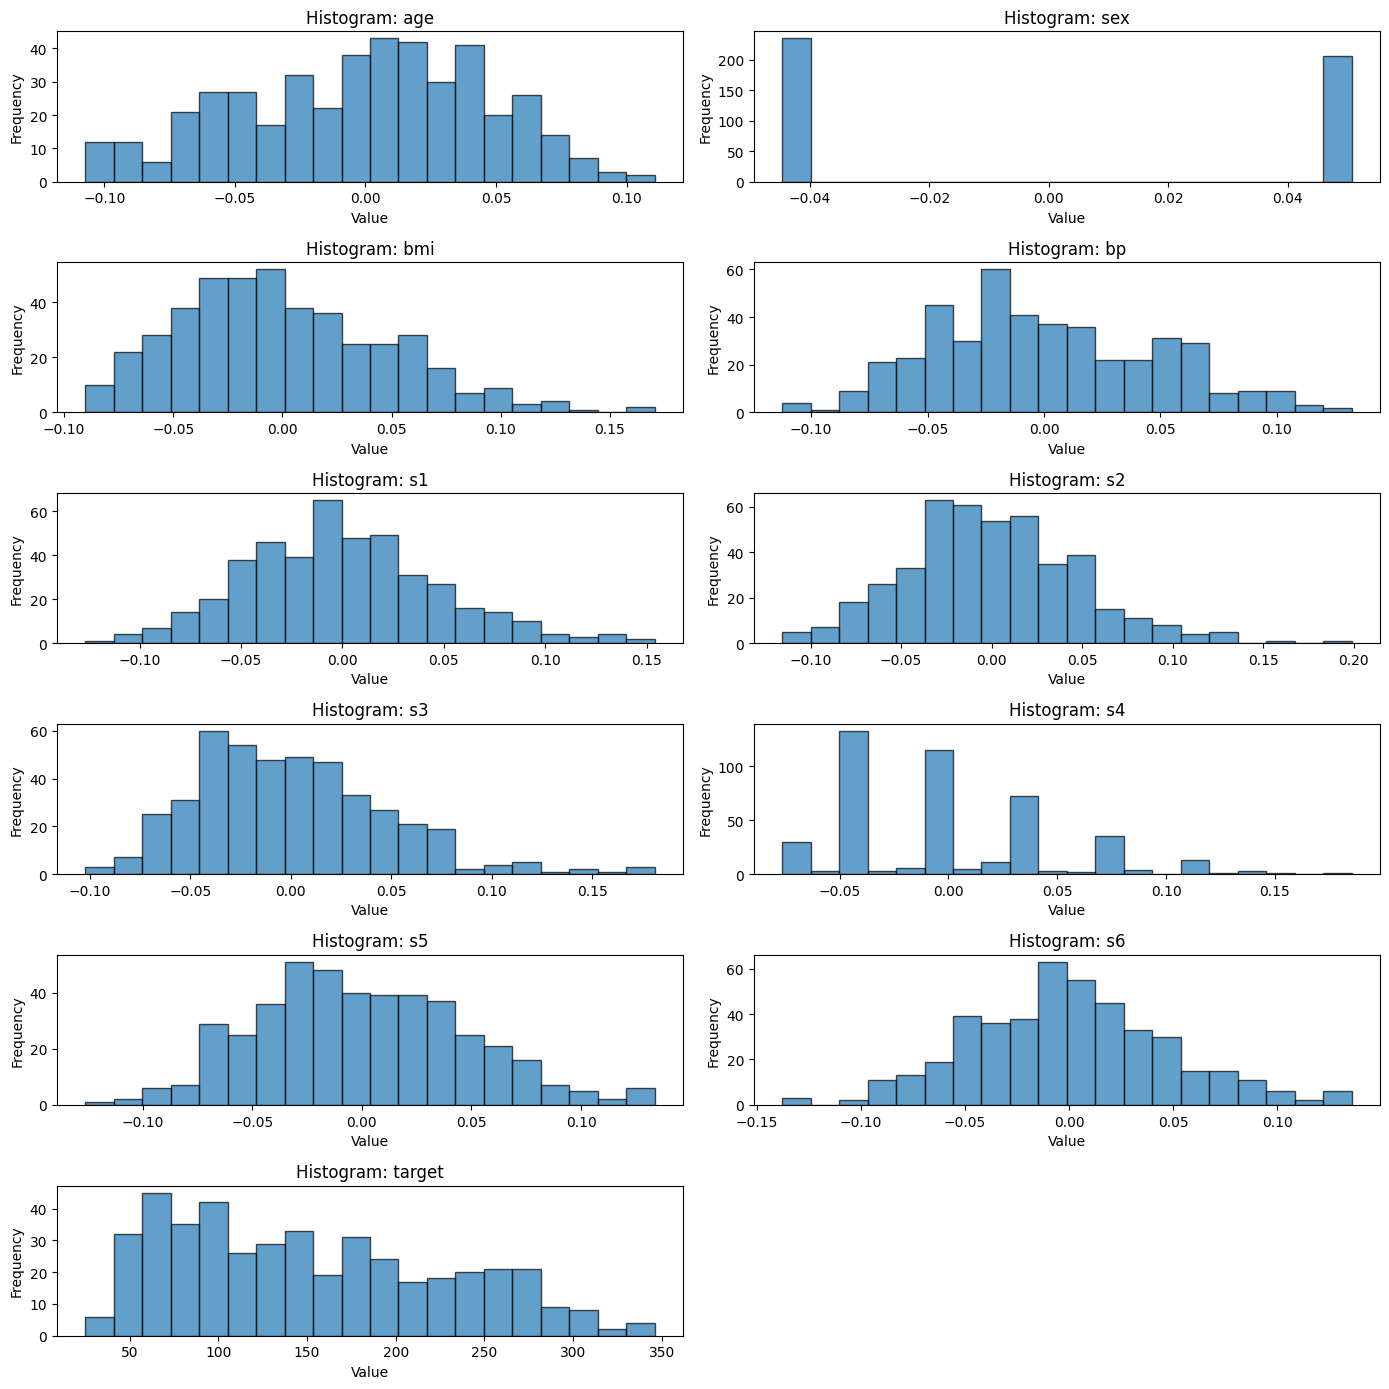


Histograms show the distribution shape (Gaussian, skewed, multimodal, etc.)


In [9]:
# Histograms for each feature (to explore distributions)
fig, axes = plt.subplots(6, 2, figsize=(14, 14))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Histogram: {col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

# Hide the extra subplot (12th subplot for 11 columns)
axes[-1].set_visible(False)

plt.tight_layout()

plt.show()
print("\nHistograms show the distribution shape (Gaussian, skewed, multimodal, etc.)")


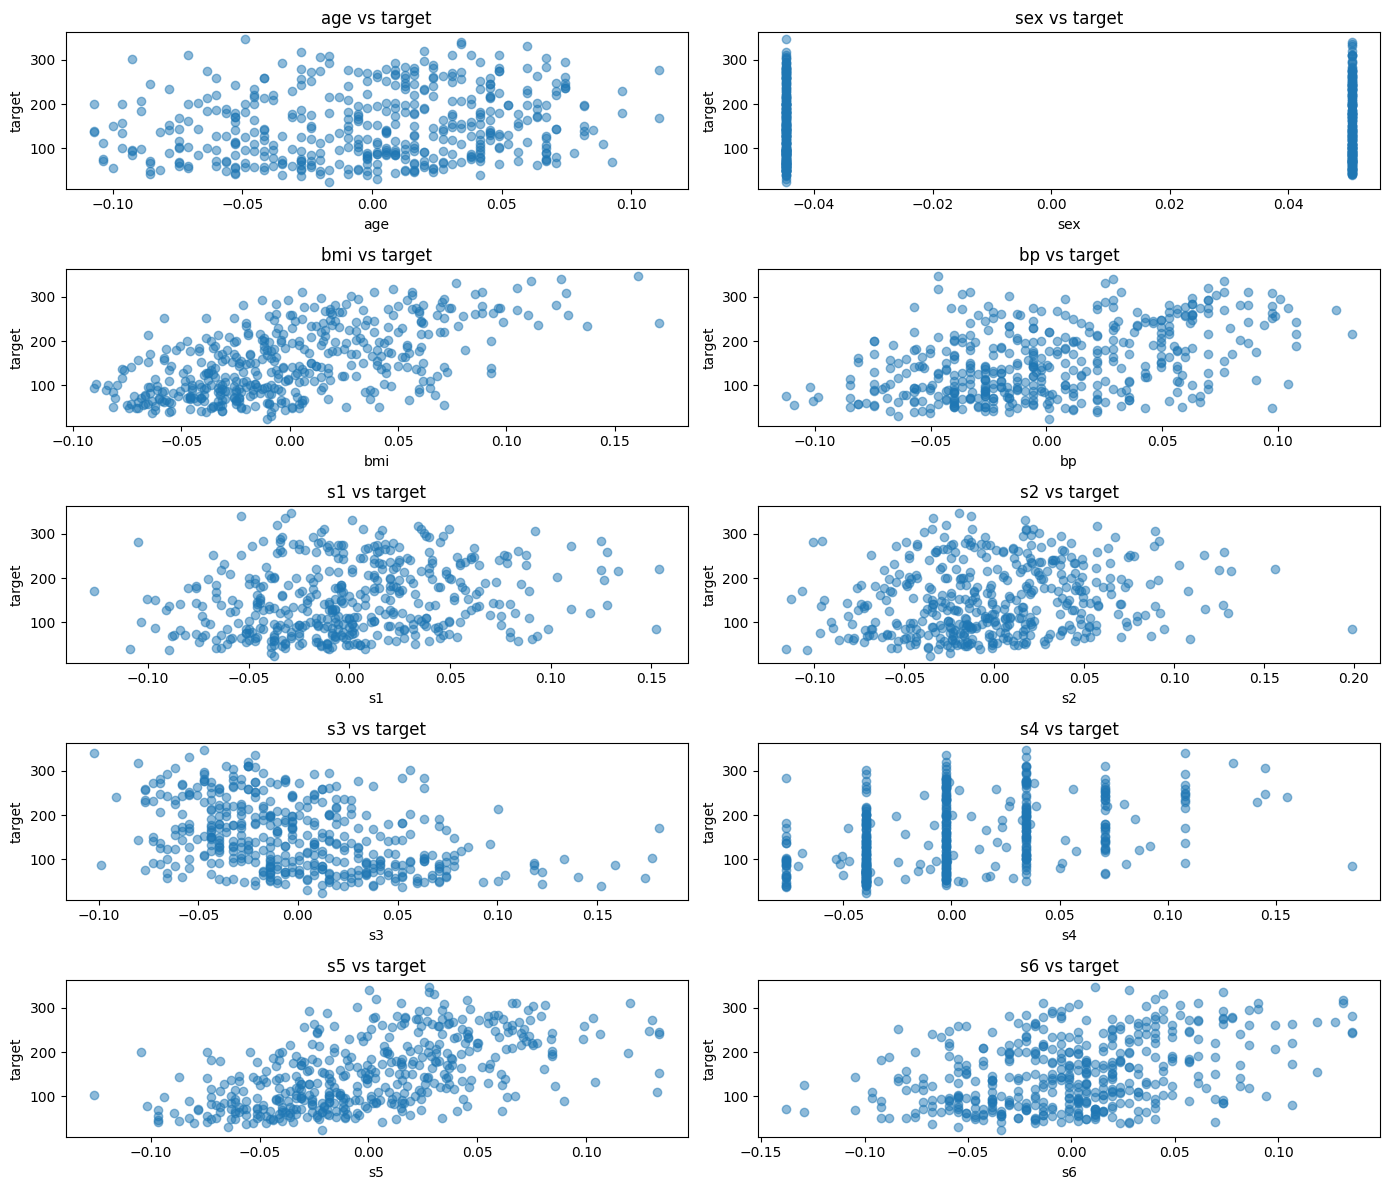


Scatter plots show relationships between features and target variable.


In [10]:
# Scatter plots (features vs target)
fig, axes = plt.subplots(5, 2, figsize=(14, 12))
axes = axes.ravel()

feature_cols = [col for col in df.columns if col != 'target']
for idx, col in enumerate(feature_cols):
    axes[idx].scatter(df[col], df['target'], alpha=0.5)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('target')
    axes[idx].set_title(f'{col} vs target')

plt.tight_layout()
plt.show()

print("\nScatter plots show relationships between features and target variable.")

In [11]:
# Scaling analysis - check range of features
print("Feature Ranges:")
print("="*60)
for col in df.columns[:-1]:  # Exclude target
    print(f"{col}: [{df[col].min():.4f}, {df[col].max():.4f}]")


Feature Ranges:
age: [-0.1072, 0.1107]
sex: [-0.0446, 0.0507]
bmi: [-0.0903, 0.1706]
bp: [-0.1124, 0.1320]
s1: [-0.1268, 0.1539]
s2: [-0.1156, 0.1988]
s3: [-0.1023, 0.1812]
s4: [-0.0764, 0.1852]
s5: [-0.1261, 0.1336]
s6: [-0.1378, 0.1356]


In [ ]:



print("\n" + "="*60)
print("Detailed Statistics:")
print("="*60)

for col in df.columns:
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():.4f}")
    print(f"  Median: {df[col].median():.4f}")
    print(f"  Std Dev: {df[col].std():.4f}")
    print(f"  Min: {df[col].min():.4f}")
    print(f"  Max: {df[col].max():.4f}")
  
    # 1. Skewness and Kurtosis
    sk = stats.skew(df[col])
    kt = stats.kurtosis(df[col])
    print(f"  Skewness: {sk:.4f} ({'Right-tailed' if sk > 0 else 'Left-tailed' if sk < 0 else 'Symmetric'})")
    print(f"  Kurtosis: {kt:.4f} ({'Leptokurtic' if kt > 0 else 'Platykurtic' if kt < 0 else 'Mesokurtic'})")
    
    # 2. Normality Testing (Shapiro-Wilk)
    # H0: The data follows a Gaussian distribution
    shapiro_stat, p_value = stats.shapiro(df[col])
    print(f"  Shapiro-Wilk Test: Stat={shapiro_stat:.4f}, p-value={p_value:.4f}")
    
    if p_value > 0.05:
        print("  Result: Data appears Gaussian (Fail to reject H0)")
    else:
        print("  Result: Data does NOT appear Gaussian (Reject H0)")



Detailed Statistics:

age:
  Mean: -0.0000
  Median: 0.0054
  Std Dev: 0.0476
  Min: -0.1072
  Max: 0.1107
  Skewness: -0.2306 (Left-tailed)
  Kurtosis: -0.6772 (Platykurtic)
  Shapiro-Wilk Test: Stat=0.9824, p-value=0.0000
  Result: Data does NOT appear Gaussian (Reject H0)

sex:
  Mean: 0.0000
  Median: -0.0446
  Std Dev: 0.0476
  Min: -0.0446
  Max: 0.0507
  Skewness: 0.1270 (Right-tailed)
  Kurtosis: -1.9839 (Platykurtic)
  Shapiro-Wilk Test: Stat=0.6351, p-value=0.0000
  Result: Data does NOT appear Gaussian (Reject H0)

bmi:
  Mean: -0.0000
  Median: -0.0073
  Std Dev: 0.0476
  Min: -0.0903
  Max: 0.1706
  Skewness: 0.5961 (Right-tailed)
  Kurtosis: 0.0805 (Leptokurtic)
  Shapiro-Wilk Test: Stat=0.9728, p-value=0.0000
  Result: Data does NOT appear Gaussian (Reject H0)

bp:
  Mean: -0.0000
  Median: -0.0057
  Std Dev: 0.0476
  Min: -0.1124
  Max: 0.1320
  Skewness: 0.2897 (Right-tailed)
  Kurtosis: -0.5403 (Platykurtic)
  Shapiro-Wilk Test: Stat=0.9837, p-value=0.0001
  Result: 

In [ ]:
#DATA PREPARATION: SCALING X ONLY ---
print("="*70)
print("DATA PREPARATION: TRAIN-TEST SPLIT & STANDARD SCALING")
print("="*70)

# Step 1: Separate features and target using column names
feature_columns = [col for col in df.columns if col != 'target']
X_raw = df[feature_columns].values
y_raw = df['target'].values.reshape(-1, 1) # Reshape for consistency

# Step 2: Train-test split (70% train, 30% test)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42
)

# Step 3: Initialize and apply Standard Scaler for Features (X) only
# Scaler for Features (X)
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train_raw)
X_test = scaler_X.transform(X_test_raw)

# Keep y as is 
y_train = y_train_raw.flatten()
y_test = y_test_raw.flatten()

print(f"\nScaling Complete:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")

# Verification: Check that X is standardized (mean ≈ 0, std ≈ 1)
print(f" Verification (X means should be ~0, X std should be ~1):")
print(f" X_train mean (avg): {np.mean(X_train):.4f}")
print(f" X_train std (avg): {np.std(X_train):.4f}")

print("\n" + "="*70)
print("DATA PREPARATION COMPLETE")
print("="*70)

DATA PREPARATION: TRAIN-TEST SPLIT & STANDARD SCALING

Scaling Complete:
  X_train shape: (309, 10)
  y_train shape: (309,)
 Verification (X means should be ~0, X std should be ~1):
 X_train mean (avg): 0.0000
 X_train std (avg): 1.0000

DATA PREPARATION COMPLETE


In [14]:
class ElasticNetRegression:
    def __init__(self, learning_rate=0.001, epochs=50000, alpha=1.0, rho=0.5):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.rho = rho  
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # alpha is the total penalty, rho is the ratio between L1 and L2
        l1_ratio = self.alpha * self.rho
        l2_ratio = self.alpha * (1.0 - self.rho)

        for _ in range(self.epochs):
            y_pred = X @ self.weights + self.bias
            errors = y_pred - y

            dw = (2.0 / n_samples) * (X.T @ errors)
            
            dw += 2.0 * l2_ratio * self.weights
            dw += l1_ratio * np.sign(self.weights)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * (2.0 / n_samples * np.sum(errors))

    def predict(self, X):
        return X @ self.weights + self.bias


In [15]:
class LassoRegression:

    def __init__(self, learning_rate=0.001, epochs=50000, lambda_=1.0):
        self.learning_rate = learning_rate   
        self.epochs = epochs
        self.lambda_ = lambda_               
        self.weights = None
        self.bias = None

    # Soft-thresholding 
    def soft_threshold(self, z, threshold):
        return np.sign(z) * np.maximum(np.abs(z) - threshold, 0.0)

    def fit(self, X, y):

        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = np.mean(y)

        for _ in range(self.epochs):
            # Gradient step 
            y_pred = X @ self.weights + self.bias
            errors = y_pred - y

            dw = (2.0 / n_samples) * (X.T @ errors)
            db = (2.0 / n_samples) * np.sum(errors)

            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db

            # Proximal/coordinate wise update 
            eta_lambda = self.learning_rate * self.lambda_
            self.weights = self.soft_threshold(self.weights, eta_lambda)

    def predict(self, X):
        return X @ self.weights + self.bias


In [16]:
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def create_kfold_splits(n_samples, n_folds=5, shuffle=True, random_state=42):
    indices = np.arange(n_samples)
    if shuffle:
        np.random.seed(random_state)
        np.random.shuffle(indices)
    fold_sizes = np.full(n_folds, n_samples // n_folds, dtype=int)
    fold_sizes[:n_samples % n_folds] += 1
    current = 0
    splits = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        val_idx = indices[start:stop]
        train_idx = np.concatenate([indices[:start], indices[stop:]]) 
        splits.append((train_idx, val_idx))
        current = stop
    return splits

In [17]:
# --- ELASTICNET TUNING ---
print("="*70)
print("ELASTICNET HYPERPARAMETER TUNING")
print("="*70)

alpha_values = np.array([0.001, 0.005, 0.01, 0.05, 0.1])
rho_values = np.array([0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95]) 
en_cv_results = []

for alpha in alpha_values:
    for rho in rho_values:
        kfold_splits = create_kfold_splits(n_samples=len(X_train), n_folds=5, shuffle=True, random_state=42)
        fold_mse = []
        fold_r2 = []  
        fold_nonzero = []
        
        for train_idx, val_idx in kfold_splits:
            model = ElasticNetRegression(learning_rate=0.001, epochs=50000, alpha=alpha, rho=rho)
            
            model.fit(X_train[train_idx], y_train[train_idx])
            
            # Get predictions on validation fold
            y_pred = model.predict(X_train[val_idx])
            
            # Compute MSE and R² (y is not scaled, so use directly)
            fold_mse.append(calculate_mse(y_train[val_idx], y_pred))
            fold_r2.append(calculate_r2(y_train[val_idx], y_pred)) 
            
            fold_nonzero.append(np.sum(model.weights != 0))
        
        avg_mse = np.mean(fold_mse)
        avg_r2 = np.mean(fold_r2) 
        se_mse = np.std(fold_mse) / np.sqrt(len(fold_mse))
        
        en_cv_results.append({
            'alpha': alpha, 
            'rho': rho,
            'cv_mse_mean': avg_mse,
            'cv_r2_mean': avg_r2,
            'cv_mse_se': se_mse,
            'nonzero_features': np.mean(fold_nonzero)
        })
        print(f"Alpha {alpha:>5.3f}, Rho {rho:>4.2f} | MSE: {avg_mse:.2f} +/- {se_mse:.2f} | Rsquare: {avg_r2:.4f} | Active: {np.mean(fold_nonzero):.1f}/10")

print("\n" + "="*70)
print("SELECTION STRATEGY 1: MINIMUM CROSS-VALIDATION MSE")
print("="*70)

# Select parameters that minimize cross-validated MSE
best_en_params = min(en_cv_results, key=lambda x: x['cv_mse_mean'])

en_alpha_min = best_en_params['alpha']
en_rho_min = best_en_params['rho']
min_mse = best_en_params['cv_mse_mean']
min_se = best_en_params['cv_mse_se']

print(f"Minimum CV MSE: {min_mse:.2f} ± {min_se:.2f}")
print(f"Selected Alpha: {en_alpha_min}, Rho: {en_rho_min}")
print(f"Active Features: {best_en_params['nonzero_features']:.1f}/10")

print("\n" + "="*70)
print("SELECTION STRATEGY 2: ONE-STANDARD-ERROR (1-SE) RULE")
print("="*70)

# 1-SE Rule: Select simplest model (highest alpha) within 1 SE of minimum MSE
threshold_1se = min_mse + min_se

# Filter candidates within 1-SE threshold
candidates_1se = [result for result in en_cv_results if result['cv_mse_mean'] <= threshold_1se]

# Among candidates, select the one with highest alpha (most regularization/simplicity)
en_1se_params = max(candidates_1se, key=lambda x: (x['alpha'], x['rho']))

en_alpha_1se = en_1se_params['alpha']
en_rho_1se = en_1se_params['rho']

print(f"1-SE Threshold: {threshold_1se:.2f}")
print(f"Number of models within 1-SE: {len(candidates_1se)}/{len(en_cv_results)}")
print(f"Selected Alpha: {en_alpha_1se}, Rho: {en_rho_1se}")
print(f"CV MSE: {en_1se_params['cv_mse_mean']:.2f} ± {en_1se_params['cv_mse_se']:.2f}")
print(f"Active Features: {en_1se_params['nonzero_features']:.1f}/10")

print("\n" + "="*70)
print("FINAL SELECTION: USING 1-SE RULE")
print("="*70)

en_alpha_final = en_alpha_1se
en_rho_final = en_rho_1se

print(f"Final Alpha: {en_alpha_final}, Rho: {en_rho_final}")

# --- FINAL ELASTICNET TRAINING ---
print("\n" + "="*70)
print("FINAL ELASTICNET TRAINING")
print("="*70)
final_en = ElasticNetRegression(learning_rate=0.001, epochs=50000, 
                                 alpha=en_alpha_final, rho=en_rho_final)
final_en.fit(X_train, y_train)

# Final Analysis
y_train_pred = final_en.predict(X_train)
y_test_pred = final_en.predict(X_test)

final_train_mse = calculate_mse(y_train, y_train_pred)
final_train_r2 = calculate_r2(y_train, y_train_pred)
final_test_mse = calculate_mse(y_test, y_test_pred)
final_test_r2 = calculate_r2(y_test, y_test_pred)

active_en = np.sum(final_en.weights != 0)

# --- RESULTS DISPLAY ---
print(f"\n" + "="*70)
print(f"FINAL ELASTICNET TRAINING (FULL DATASET)")
print("="*70)

print(f"\n" + "="*40)
print(f"FINAL ELASTICNET RESULTS (Alpha: {en_alpha_final:.4f}, Rho: {en_rho_final:.2f})")
print(f"Train R-squared: {final_train_r2:.4f}")
print(f"Test R-squared: {final_test_r2:.4f}")
print(f"Features Kept: {active_en}/10")
print("="*40)

feature_names = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
for name, w in zip(feature_names, final_en.weights):
    status = "ACTIVE" if w != 0.0 else "ELIMINATED"
    print(f"{name:<10} | {w:>10.6f} | {status}")


eliminated_en = [name for name, w in zip(feature_names, final_en.weights) if w == 0.0]
if eliminated_en:
    print(f"\nEliminated features: {', '.join(eliminated_en)}")
else:
    print("\nNo features were eliminated.")

ELASTICNET HYPERPARAMETER TUNING
Alpha 0.001, Rho 0.10 | MSE: 3209.82 +/- 144.43 | Rsquare: 0.4711 | Active: 10.0/10
Alpha 0.001, Rho 0.30 | MSE: 3210.03 +/- 144.60 | Rsquare: 0.4711 | Active: 10.0/10
Alpha 0.001, Rho 0.50 | MSE: 3210.24 +/- 144.78 | Rsquare: 0.4710 | Active: 10.0/10
Alpha 0.001, Rho 0.70 | MSE: 3210.45 +/- 144.96 | Rsquare: 0.4710 | Active: 10.0/10
Alpha 0.001, Rho 0.80 | MSE: 3210.56 +/- 145.05 | Rsquare: 0.4710 | Active: 10.0/10
Alpha 0.001, Rho 0.90 | MSE: 3210.67 +/- 145.14 | Rsquare: 0.4710 | Active: 10.0/10
Alpha 0.001, Rho 0.95 | MSE: 3210.73 +/- 145.19 | Rsquare: 0.4710 | Active: 10.0/10
Alpha 0.005, Rho 0.10 | MSE: 3206.62 +/- 141.61 | Rsquare: 0.4715 | Active: 10.0/10
Alpha 0.005, Rho 0.30 | MSE: 3207.40 +/- 142.31 | Rsquare: 0.4714 | Active: 10.0/10
Alpha 0.005, Rho 0.50 | MSE: 3208.24 +/- 143.05 | Rsquare: 0.4713 | Active: 10.0/10
Alpha 0.005, Rho 0.70 | MSE: 3209.17 +/- 143.84 | Rsquare: 0.4712 | Active: 10.0/10
Alpha 0.005, Rho 0.80 | MSE: 3209.66 +/- 14

In [18]:
# LASSO TUNING
print("="*70)
print("LASSO HYPERPARAMETER TUNING")
print("="*70)

lasso_lambda_values = np.array([0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0, 1.5, 2.0, 5.0])
lasso_cv_results = []

for lambda_val in lasso_lambda_values:
    kfold_splits = create_kfold_splits(n_samples=len(X_train), n_folds=5, shuffle=True, random_state=42)
    fold_mse = []
    fold_r2 = []
    fold_nonzero = []
    
    for train_idx, val_idx in kfold_splits:
        model = LassoRegression(learning_rate=0.001, epochs=50000, lambda_=lambda_val)
        
        # Soft Thresholding 
        # The L1 penalty math inside fit() gradually shrinks coefficients.
        model.fit(X_train[train_idx], y_train[train_idx])
        
        # Get predictions on validation fold
        y_pred = model.predict(X_train[val_idx])
        
        # Compute MSE and R² (y is not scaled, so use directly)
        fold_mse.append(calculate_mse(y_train[val_idx], y_pred))
        fold_r2.append(calculate_r2(y_train[val_idx], y_pred))
        
        # We now count any weight that is NOT exactly 0.0
        fold_nonzero.append(np.sum(model.weights != 0))
    
    avg_mse = np.mean(fold_mse)
    avg_r2 = np.mean(fold_r2)
    se_mse = np.std(fold_mse) / np.sqrt(len(fold_mse))
    
    lasso_cv_results.append({
        'lambda': lambda_val,
        'cv_mse_mean': avg_mse,
        'cv_r2_mean': avg_r2,
        'cv_mse_se': se_mse,
        'nonzero_features': np.mean(fold_nonzero)
    })
    print(f"Lambda {lambda_val:>5.3f} | MSE: {avg_mse:.2f} +/- {se_mse:.2f} | Rsquare: {avg_r2:.4f} | Active: {np.mean(fold_nonzero):.1f}/10")

print("\n" + "="*70)
print("SELECTION STRATEGY 1: MINIMUM CROSS-VALIDATION MSE")
print("="*70)

# Select lambda that minimizes cross-validated MSE
best_lasso_params = min(lasso_cv_results, key=lambda x: x['cv_mse_mean'])
lasso_lambda_min = best_lasso_params['lambda']
min_mse = best_lasso_params['cv_mse_mean']
min_se = best_lasso_params['cv_mse_se']

print(f"Minimum CV MSE: {min_mse:.2f} ± {min_se:.2f}")
print(f"Selected Lambda: {lasso_lambda_min}")
print(f"Active Features: {best_lasso_params['nonzero_features']:.1f}/10")

print("\n" + "="*70)
print("SELECTION STRATEGY 2: ONE-STANDARD-ERROR (1-SE) RULE")
print("="*70)

# 1-SE Rule: Select simplest model (highest lambda) within 1 SE of minimum MSE
threshold_1se = min_mse + min_se

# Filter candidates within 1-SE threshold
candidates_1se = [result for result in lasso_cv_results if result['cv_mse_mean'] <= threshold_1se]

# Among candidates, select the one with highest lambda (most regularization/simplicity)
lasso_1se_params = max(candidates_1se, key=lambda x: x['lambda'])

lasso_lambda_1se = lasso_1se_params['lambda']

print(f"1-SE Threshold: {threshold_1se:.2f}")
print(f"Number of models within 1-SE: {len(candidates_1se)}/{len(lasso_cv_results)}")
print(f"Selected Lambda: {lasso_lambda_1se}")
print(f"CV MSE: {lasso_1se_params['cv_mse_mean']:.2f} ± {lasso_1se_params['cv_mse_se']:.2f}")
print(f"Active Features: {lasso_1se_params['nonzero_features']:.1f}/10")

print("\n" + "="*70)
print("FINAL SELECTION: USING 1-SE RULE")
print("="*70)

lasso_lambda_final = lasso_lambda_1se

print(f"Final Lambda: {lasso_lambda_final}")

# FINAL LASSO TRAINING
print("\n" + "="*70)
print("FINAL LASSO TRAINING (FULL DATASET)")
print("="*70)
lasso_final = LassoRegression(learning_rate=0.001, epochs=50000, lambda_=lasso_lambda_final)
lasso_final.fit(X_train, y_train)


# Final Analysis
y_train_pred = lasso_final.predict(X_train)
y_test_pred = lasso_final.predict(X_test)

final_train_mse = calculate_mse(y_train, y_train_pred)
final_train_r2 = calculate_r2(y_train, y_train_pred)
final_test_mse = calculate_mse(y_test, y_test_pred)
final_test_r2 = calculate_r2(y_test, y_test_pred)

active_count = np.sum(lasso_final.weights != 0)

print(f"\n" + "="*40)
print(f"FINAL LASSO RESULTS (Lambda: {lasso_lambda_final})")
print(f"Train R-squared: {final_train_r2:.4f}")
print(f"Test R-squared: {final_test_r2:.4f}")
print(f"Features Kept: {active_count}/10")
print("="*40)

feature_names = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
for name, w in zip(feature_names, lasso_final.weights):
    status = "ACTIVE" if w != 0.0 else "ELIMINATED"
    print(f"{name:<10} | {w:>10.6f} | {status}")


eliminated = [name for name, w in zip(feature_names, lasso_final.weights) if w == 0.0]
if eliminated:
    print(f"\nEliminated features: {', '.join(eliminated)}")
else:
    print("\nNo features were eliminated.")

LASSO HYPERPARAMETER TUNING
Lambda 0.010 | MSE: 3210.57 +/- 144.97 | Rsquare: 0.4710 | Active: 10.0/10
Lambda 0.050 | MSE: 3209.96 +/- 144.18 | Rsquare: 0.4711 | Active: 10.0/10
Lambda 0.100 | MSE: 3209.42 +/- 143.18 | Rsquare: 0.4711 | Active: 9.8/10
Lambda 0.200 | MSE: 3208.72 +/- 141.23 | Rsquare: 0.4711 | Active: 9.8/10
Lambda 0.500 | MSE: 3207.13 +/- 136.67 | Rsquare: 0.4711 | Active: 9.4/10
Lambda 0.800 | MSE: 3204.86 +/- 134.09 | Rsquare: 0.4714 | Active: 9.2/10
Lambda 1.000 | MSE: 3204.15 +/- 132.69 | Rsquare: 0.4714 | Active: 9.2/10
Lambda 1.500 | MSE: 3208.57 +/- 131.47 | Rsquare: 0.4705 | Active: 8.8/10
Lambda 2.000 | MSE: 3216.81 +/- 131.09 | Rsquare: 0.4691 | Active: 8.6/10
Lambda 5.000 | MSE: 3216.35 +/- 116.28 | Rsquare: 0.4688 | Active: 6.6/10

SELECTION STRATEGY 1: MINIMUM CROSS-VALIDATION MSE
Minimum CV MSE: 3204.15 ± 132.69
Selected Lambda: 1.0
Active Features: 9.2/10

SELECTION STRATEGY 2: ONE-STANDARD-ERROR (1-SE) RULE
1-SE Threshold: 3336.84
Number of models withi

In [19]:
# Train final models with best hyperparameters
print("\n" + "="*70)
print("TRAINING FINAL MODELS WITH BEST HYPERPARAMETERS")
print("="*70)

# ElasticNet already trained with 50,000 epochs in previous cell
print(f"\nUsing ElasticNet trained with alpha={en_alpha_final:.4f}, rho={en_rho_final:.2f} (50,000 epochs)")
final_en_model = final_en

# Lasso already trained with 50,000 epochs in previous cell
print(f"Using Lasso trained with lambda={lasso_lambda_final} (50,000 epochs)")
final_lasso_model = lasso_final 

# Train baseline Linear Regression (sklearn)
print("\nTraining Linear Regression (baseline)...")
lr_sklearn = LinearRegression()
lr_sklearn.fit(X_train, y_train)

# Get predictions
en_train_pred = final_en_model.predict(X_train)
en_test_pred = final_en_model.predict(X_test)

lasso_train_pred = final_lasso_model.predict(X_train)
lasso_test_pred = final_lasso_model.predict(X_test)

lr_train_pred = lr_sklearn.predict(X_train)
lr_test_pred = lr_sklearn.predict(X_test)

# Calculate MSE (y is not scaled, so use directly)
en_train_mse_original = mean_squared_error(y_train, en_train_pred)
en_test_mse_original = mean_squared_error(y_test, en_test_pred)

lasso_train_mse_original = mean_squared_error(y_train, lasso_train_pred)
lasso_test_mse_original = mean_squared_error(y_test, lasso_test_pred)

lr_train_mse_original = mean_squared_error(y_train, lr_train_pred)
lr_test_mse_original = mean_squared_error(y_test, lr_test_pred)

# Calculate R²
en_train_r2_original = r2_score(y_train, en_train_pred)
en_test_r2_original = r2_score(y_test, en_test_pred)

lasso_train_r2_original = r2_score(y_train, lasso_train_pred)
lasso_test_r2_original = r2_score(y_test, lasso_test_pred)

lr_train_r2_original = r2_score(y_train, lr_train_pred)
lr_test_r2_original = r2_score(y_test, lr_test_pred)

print("\n" + "="*70)
print("MODEL EVALUATION RESULTS (ORIGINAL SCALE)")
print("="*70)

print("\nTraining Set Performance:")
print(f"  ElasticNet: MSE={en_train_mse_original:.6f}, R²={en_train_r2_original:.6f}")
print(f"  Lasso:      MSE={lasso_train_mse_original:.6f}, R²={lasso_train_r2_original:.6f}")
print(f"  LinearReg:  MSE={lr_train_mse_original:.6f}, R²={lr_train_r2_original:.6f}")

print("\nTest Set Performance:")
print(f"  ElasticNet: MSE={en_test_mse_original:.6f}, R²={en_test_r2_original:.6f}")
print(f"  Lasso:      MSE={lasso_test_mse_original:.6f}, R²={lasso_test_r2_original:.6f}")
print(f"  LinearReg:  MSE={lr_test_mse_original:.6f}, R²={lr_test_r2_original:.6f}")


TRAINING FINAL MODELS WITH BEST HYPERPARAMETERS

Using ElasticNet trained with alpha=0.1000, rho=0.95 (50,000 epochs)
Using Lasso trained with lambda=5.0 (50,000 epochs)

Training Linear Regression (baseline)...

MODEL EVALUATION RESULTS (ORIGINAL SCALE)

Training Set Performance:
  ElasticNet: MSE=2933.113998, R²=0.522938
  Lasso:      MSE=3005.520009, R²=0.511161
  LinearReg:  MSE=2924.046379, R²=0.524412

Test Set Performance:
  ElasticNet: MSE=2820.174867, R²=0.477582
  Lasso:      MSE=2780.525450, R²=0.484926
  LinearReg:  MSE=2821.750981, R²=0.477290



EXAMINING LEARNED FEATURE COEFFICIENTS

1. ELASTICNET COEFFICIENTS
----------------------------------------------------------------------
Alpha: 0.1000, Rho: 0.95

Feature Coefficients:
              age:   1.503587
              sex: -12.162709
              bmi:  26.589458
               bp:  18.287860
               s1: -21.269044
               s2:   7.183645
               s3:  -3.794289
               s4:  10.816811
               s5:  23.021004
               s6:   2.259937

Bias: 153.902913
Non-zero coefficients: 10/10
ElasticNet eliminated features: none

2. LASSO COEFFICIENTS
----------------------------------------------------------------------
Lambda: 5.0000

Feature Coefficients:
              age:   0.000000
              sex:  -7.637639
              bmi:  26.736240
               bp:  15.914370
               s1:  -1.908220
               s2:  -0.000000
               s3: -12.822499
               s4:   0.000000
               s5:  17.263505
               s6:   0.9095

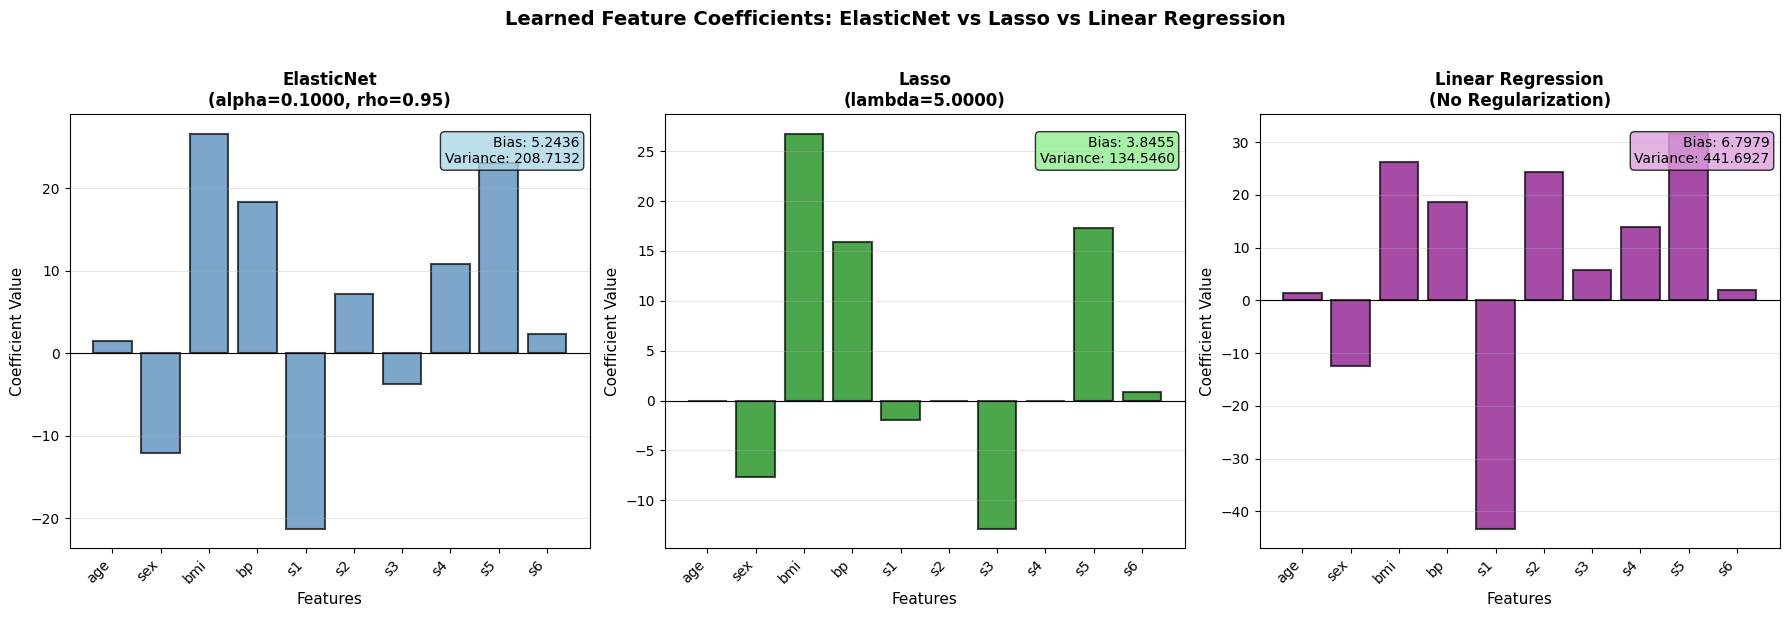

In [20]:
print("\n" + "="*70)
print("EXAMINING LEARNED FEATURE COEFFICIENTS")
print("="*70)

# Get feature names (all columns except 'target')
if 'target' not in df.columns:
    raise ValueError("Error: 'target' column not found in dataset!")
feature_names = [col for col in df.columns if col != 'target']

# Display coefficients for all three models
print("\n1. ELASTICNET COEFFICIENTS")
print("-" * 70)
print(f"Alpha: {en_alpha_final:.4f}, Rho: {en_rho_final:.2f}")
print("\nFeature Coefficients:")
for i, name in enumerate(feature_names):
    print(f"  {name:>15}: {final_en_model.weights[i]:>10.6f}")
print(f"\nBias: {final_en_model.bias:.6f}")
print(f"Non-zero coefficients: {np.sum(np.abs(final_en_model.weights) > 1e-2)}/10")

# List eliminated features for ElasticNet
en_zero_idx = np.where(np.abs(final_en_model.weights) < 1e-2)[0]
if len(en_zero_idx) == 0:
    print("ElasticNet eliminated features: none")
else:
    en_zero_features = [feature_names[i] for i in en_zero_idx]
    print(f"ElasticNet eliminated features: {en_zero_features}")

print("\n" + "="*70)
print("2. LASSO COEFFICIENTS")
print("-" * 70)
print(f"Lambda: {lasso_lambda_final:.4f}")
print("\nFeature Coefficients:")
for i, name in enumerate(feature_names):
    print(f"  {name:>15}: {final_lasso_model.weights[i]:>10.6f}")
print(f"\nBias: {final_lasso_model.bias:.6f}")
print(f"Non-zero coefficients: {np.sum(np.abs(final_lasso_model.weights) > 1e-2)}/10")

# List eliminated features for Lasso
lasso_zero_idx = np.where(np.abs(final_lasso_model.weights) < 1e-2)[0]
if len(lasso_zero_idx) == 0:
    print("Lasso eliminated features: none")
else:
    lasso_zero_features = [feature_names[i] for i in lasso_zero_idx]
    print(f"Lasso eliminated features: {lasso_zero_features}")

print("\n" + "="*70)
print("3. LINEAR REGRESSION COEFFICIENTS")
print("-" * 70)
print("\nFeature Coefficients:")
for i, name in enumerate(feature_names):
    print(f"  {name:>15}: {lr_sklearn.coef_[i]:>10.6f}")
print(f"\nIntercept: {lr_sklearn.intercept_:.6f}")
print(f"Non-zero coefficients: 10/10 (all features used)")

# Create visualizations
print("\n" + "="*70)
print("COEFFICIENT COMPARISON VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ElasticNet coefficients
ax = axes[0]
ax.bar(range(len(feature_names)), final_en_model.weights, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_title(f'ElasticNet\n(alpha={en_alpha_final:.4f}, rho={en_rho_final:.2f})', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Features', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)
bias_en = np.mean(final_en_model.weights)
var_en = np.var(final_en_model.weights)
ax.text(0.98, 0.95, f'Bias: {bias_en:.4f}\nVariance: {var_en:.4f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Lasso coefficients
ax = axes[1]
ax.bar(range(len(feature_names)), final_lasso_model.weights, color='green', alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_title(f'Lasso\n(lambda={lasso_lambda_final:.4f})', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Features', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)
bias_lasso = np.mean(final_lasso_model.weights)
var_lasso = np.var(final_lasso_model.weights)
ax.text(0.98, 0.95, f'Bias: {bias_lasso:.4f}\nVariance: {var_lasso:.4f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Linear Regression coefficients
ax = axes[2]
ax.bar(range(len(feature_names)), lr_sklearn.coef_, color='purple', alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_title('Linear Regression\n(No Regularization)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Features', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)
bias_lr = np.mean(lr_sklearn.coef_)
var_lr = np.var(lr_sklearn.coef_)
ax.text(0.98, 0.95, f'Bias: {bias_lr:.4f}\nVariance: {var_lr:.4f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='plum', alpha=0.8))

plt.suptitle('Learned Feature Coefficients: ElasticNet vs Lasso vs Linear Regression', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

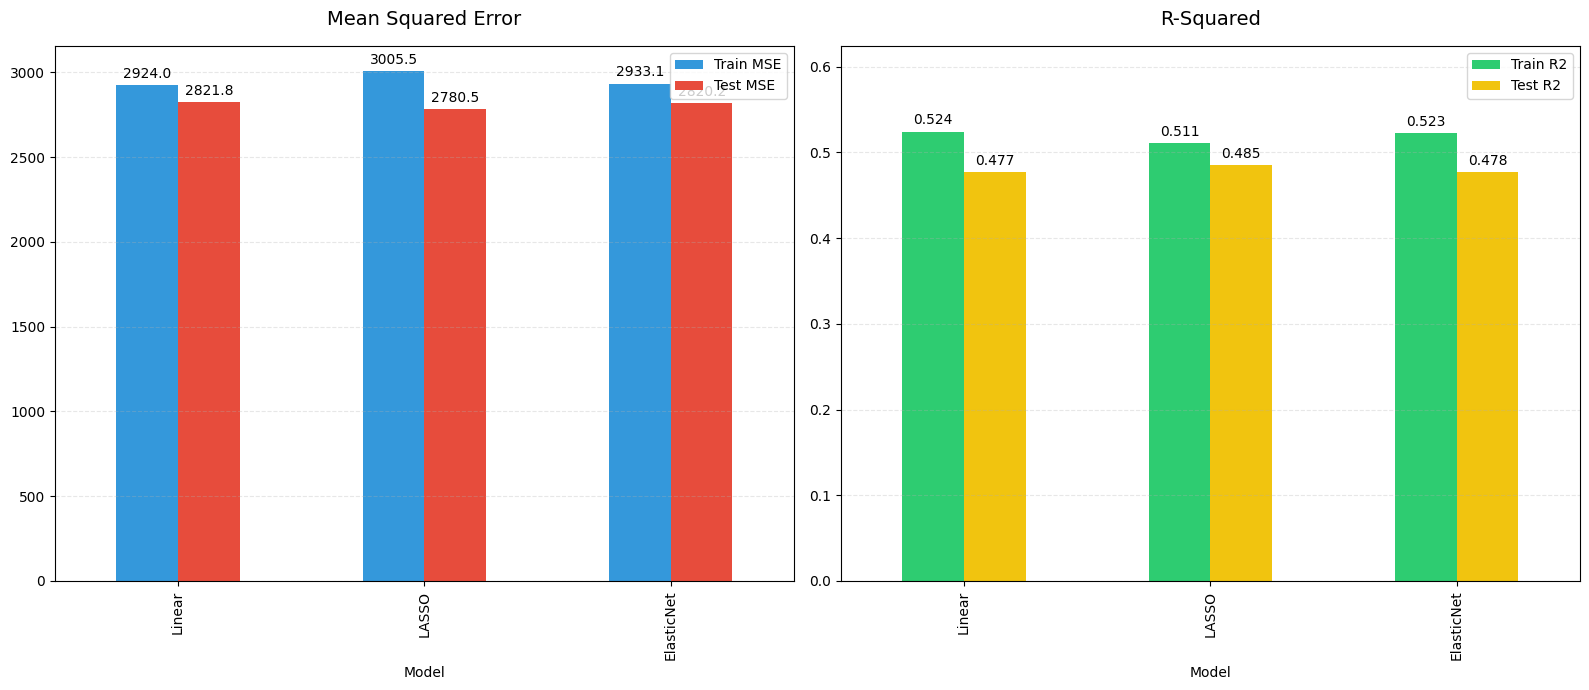


FINAL PERFORMANCE SUMMARY
     Model   Train MSE    Test MSE  Train R2  Test R2
    Linear 2924.046379 2821.750981  0.524412 0.477290
     LASSO 3005.520009 2780.525450  0.511161 0.484926
ElasticNet 2933.113998 2820.174867  0.522938 0.477582
----------------------------------------------------------------------
: The LASSO model performed best on the Test Set (Rsquare = 0.4849).


In [ ]:
# 1. Helper Function to collect metrics
def get_metrics(model, X, y):
    y_pred = model.predict(X)
    mse = calculate_mse(y, y_pred)
    r2 = calculate_r2(y, y_pred)
    return mse, r2

# 2. Collect results for all models
models = {
    'Linear': lr_sklearn,
    'LASSO': lasso_final,
    'ElasticNet': final_en
}

results = []
for name, model in models.items():
    train_mse, train_r2 = get_metrics(model, X_train, y_train)
    test_mse, test_r2 = get_metrics(model, X_test, y_test)

    results.append({
        'Model': name,
        'Train MSE': train_mse, 'Test MSE': test_mse,
        'Train R2': train_r2, 'Test R2': test_r2
    })

df_results = pd.DataFrame(results)

# 3. Identify the best model based on Test R2
best_model_name = df_results.loc[df_results['Test R2'].idxmax(), 'Model']
best_model_r2 = df_results['Test R2'].max()

# 4. Plotting the Bar Charts
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: MSE Comparison
mse_plot = df_results.plot(x='Model', y=['Train MSE', 'Test MSE'], kind='bar', ax=ax[0], color=['#3498db', '#e74c3c'])
ax[0].set_title('Mean Squared Error', fontsize=14, pad=15)
ax[0].grid(axis='y', linestyle='--', alpha=0.3)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.1f', padding=3)

# Plot 2: R2 Comparison
r2_plot = df_results.plot(x='Model', y=['Train R2', 'Test R2'], kind='bar', ax=ax[1], color=['#2ecc71', '#f1c40f'])
ax[1].set_title('R-Squared', fontsize=14, pad=15)
ax[1].set_ylim(0, df_results[['Train R2', 'Test R2']].max().max() + 0.1)
ax[1].grid(axis='y', linestyle='--', alpha=0.3)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

# 5. Print Summary Table and Identification
print("\n" + "="*70)
print("FINAL PERFORMANCE SUMMARY")
print("="*70)
print(df_results.to_string(index=False))
print("-" * 70)
print(f": The {best_model_name} model performed best on the Test Set (Rsquare = {best_model_r2:.4f}).")
print("="*70)

In [ ]:
# --- TASK 1: Data Acquisition & Analysis 
digits = load_digits()
X, y = digits.data, digits.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)



Shape of X: (1797, 64)
Shape of y: (1797,)


In [2]:
# Check for missing values 
print("Missing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum())

# Statistical Analysis 
print("Feature means:", X.mean(axis=0)[:5])
print("Feature min:", X.min())
print("Feature max:", X.max())

Missing values in X: 0
Missing values in y: 0
Feature means: [ 0.          0.30383973  5.20478575 11.83583751 11.84808013]
Feature min: 0.0
Feature max: 16.0


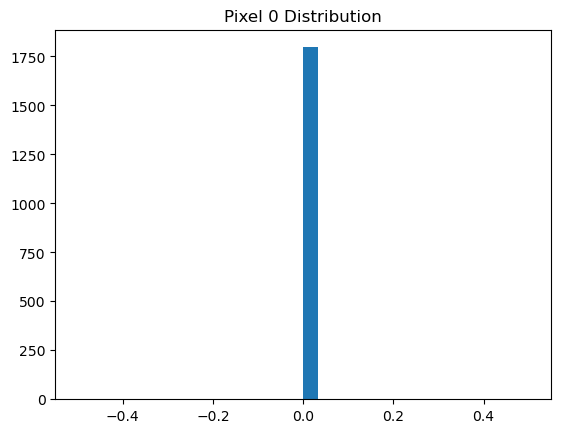

In [3]:
# Plots
plt.hist(X[:,0], bins=30)
plt.title("Pixel 0 Distribution")
plt.show()

In [4]:
# Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

In [6]:
# --- TASK 2: Multiclass SVM from Scratch ---

class MulticlassSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, epochs=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.epochs = epochs

    def fit(self, X, y):

        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # One weight vector per class
        self.W = np.zeros((n_classes, n_features))
        self.b = np.zeros(n_classes)

        # One-vs-rest training
        for idx, c in enumerate(self.classes):

            # Convert labels to +1 / -1
            y_binary = np.where(y == c, 1, -1)

            w = np.zeros(n_features)
            b = 0

            # Gradient descent
            for _ in range(self.epochs):

                # Margins
                margins = y_binary * (X @ w + b)

                # Hinge loss violations
                mask = margins < 1

                # Compute gradients
                if np.any(mask):

                    X_mis = X[mask]
                    y_mis = y_binary[mask]

                    dw = self.lambda_param * w - (X_mis.T @ y_mis) / len(y_mis)
                    db = -np.mean(y_mis)

                else:
                    # Only regularization remains
                    dw = self.lambda_param * w
                    db = 0

                # Update parameters
                w -= self.lr * dw
                b -= self.lr * db

            self.W[idx] = w
            self.b[idx] = b

    def predict(self, X):

        # Decision scores
        scores = X @ self.W.T + self.b

        # Class prediction
        return self.classes[np.argmax(scores, axis=1)]


In [7]:
# Hyperparameter tuning
learning_rates = [0.0005, 0.001, 0.005]
lambdas = [0.001, 0.01, 0.1]
epochs_list = [500, 1000, 2000]

best_acc = 0
best_params = {}

print("Starting Hyperparameter Tuning...\n")

for lr in learning_rates:
    for lmbd in lambdas:
        for epochs in epochs_list:

            svm = MulticlassSVM(
                learning_rate=lr,
                lambda_param=lmbd,
                epochs=epochs
            )

            svm.fit(X_train, y_train)
            preds = svm.predict(X_test)

            acc = accuracy_score(y_test, preds)

            print(
                f"LR={lr}, Lambda={lmbd}, Epochs={epochs} → Acc={acc:.4f}"
            )

            if acc > best_acc:
                best_acc = acc
                best_params = {
                    "learning_rate": lr,
                    "lambda": lmbd,
                    "epochs": epochs
                }

print("\nBest Accuracy:", best_acc)
print("Best Parameters:", best_params)


Starting Hyperparameter Tuning...



LR=0.0005, Lambda=0.001, Epochs=500 → Acc=0.8685
LR=0.0005, Lambda=0.001, Epochs=1000 → Acc=0.8704
LR=0.0005, Lambda=0.001, Epochs=2000 → Acc=0.9037
LR=0.0005, Lambda=0.01, Epochs=500 → Acc=0.8685
LR=0.0005, Lambda=0.01, Epochs=1000 → Acc=0.8704
LR=0.0005, Lambda=0.01, Epochs=2000 → Acc=0.9037
LR=0.0005, Lambda=0.1, Epochs=500 → Acc=0.8685
LR=0.0005, Lambda=0.1, Epochs=1000 → Acc=0.8685
LR=0.0005, Lambda=0.1, Epochs=2000 → Acc=0.9037
LR=0.001, Lambda=0.001, Epochs=500 → Acc=0.8704
LR=0.001, Lambda=0.001, Epochs=1000 → Acc=0.9037
LR=0.001, Lambda=0.001, Epochs=2000 → Acc=0.9444
LR=0.001, Lambda=0.01, Epochs=500 → Acc=0.8704
LR=0.001, Lambda=0.01, Epochs=1000 → Acc=0.9037
LR=0.001, Lambda=0.01, Epochs=2000 → Acc=0.9444
LR=0.001, Lambda=0.1, Epochs=500 → Acc=0.8685
LR=0.001, Lambda=0.1, Epochs=1000 → Acc=0.9037
LR=0.001, Lambda=0.1, Epochs=2000 → Acc=0.9444
LR=0.005, Lambda=0.001, Epochs=500 → Acc=0.9500
LR=0.005, Lambda=0.001, Epochs=1000 → Acc=0.9611
LR=0.005, Lambda=0.001, Epochs=2000 

In [8]:
# Train best SVM model
best_svm = MulticlassSVM(
    learning_rate=best_params["learning_rate"],
    lambda_param=best_params["lambda"],
    epochs=best_params["epochs"]
)

best_svm.fit(X_train, y_train)

svm_preds = best_svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_preds)

print("Final Scratch SVM Accuracy:", svm_acc)

Final Scratch SVM Accuracy: 0.9666666666666667


In [ ]:
# Random Forest Baseline, Classification Comparison

# Train Random Forest (baseline model)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

# Predict
rf_preds = rf.predict(X_test)

# Accuracy
rf_acc = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.9722222222222222


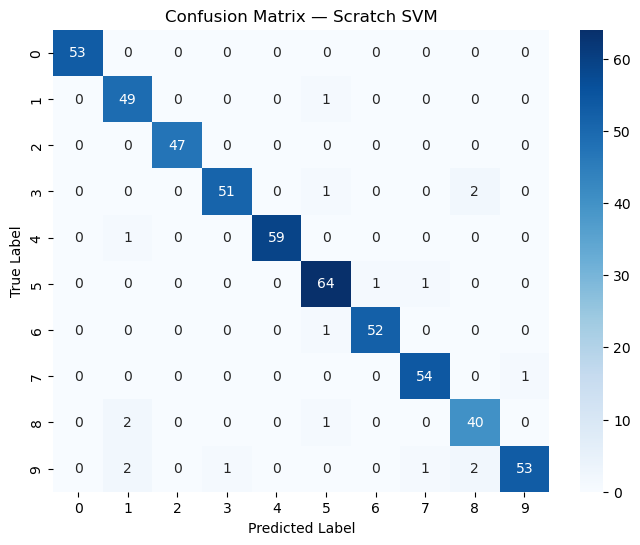

In [ ]:
# Confusion Matrix for SVM

cm = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Scratch SVM")

plt.show()



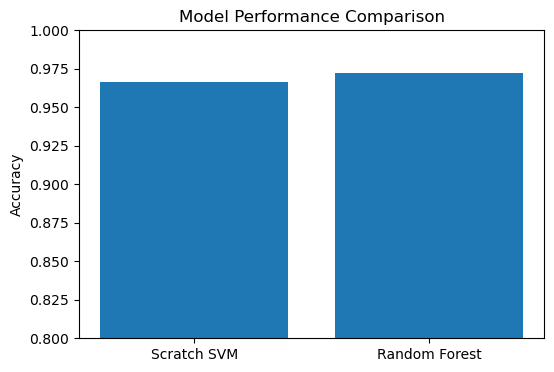

In [11]:
# Performance Comparison Plot

models = ["Scratch SVM", "Random Forest"]
accuracies = [
    accuracy_score(y_test, svm_preds),
    rf_acc
]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies)
plt.ylim(0.8, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.show()
